# Main Code

## Log Functions

In [2]:
import pprint
import matplotlib.pyplot as plt
import numpy as np

def pretty_print(title, obj, precision=4):
    print(f"\n=== {title} ===")
    
    if isinstance(obj, dict):
        for k, v in obj.items():
            if isinstance(v, (float, np.floating)):
                print(f"{str(k):>20}: {float(v):.{precision}g}")
            else:
                print(f"{str(k):>20}: {v}")
    elif isinstance(obj, (list, tuple)):
        for i, v in enumerate(obj):
            if isinstance(v, (float, np.floating)):
                print(f"[{i}] {float(v):.{precision}g}")
            else:
                print(f"[{i}] {v}")
    else:
        pprint.pprint(obj)
        
def plot_speaker_distribution(distribution, title="Speaker Distribution", alpha=1.0):
    """Plot speaker distribution over utterances (q2, predicate) in a fixed order."""
    utterance_order = [
        ("none", "ineffective"),
        ("none", "effective"),
        ("some", "ineffective"),
        ("some", "effective"),
        ("most", "ineffective"),
        ("most", "effective"),
        ("all", "ineffective"),
        ("all", "effective"),
    ]

    utterances = [f"{q2} {pred}" for (q2, pred) in utterance_order]
    probs = [distribution.get((q2, pred), 0.0) for (q2, pred) in utterance_order]

    plt.figure(figsize=(8, 5))
    bars = plt.barh(utterances, probs, color="steelblue")
    plt.xlabel("Probability")
    if alpha > 0:
        plt.title(f"{title} (α={alpha})")
    else:
        plt.title(title)
    plt.xlim(0, 1)

    # Add text labels
    for bar, prob in zip(bars, probs):
        if prob > 0.01:
            plt.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
                     f"{prob:.2f}", va="center", fontsize=9)

    plt.gca().invert_yaxis()  # Keep top-down order
    plt.tight_layout()

## Env Functions

In [3]:
from scipy.special import binom
import math
from functools import lru_cache

def generate_all_observations(world_parameters):
    """
    Generate all possible observation histograms for n patients and m sessions.
    Each histogram is a tuple of length m+1, summing to n.
    """
    n = world_parameters["n"]
    m = world_parameters["m"]
    observations = []

    def helper(current, depth, remaining):
        if depth == m:
            current.append(remaining)
            observations.append(tuple(current))
            current.pop()
            return
        for i in range(remaining + 1):
            current.append(i)
            helper(current, depth + 1, remaining - i)
            current.pop()

    helper([], 0, n)
    return observations

@lru_cache(maxsize=None)
def utterance_is_true(u, obs):
    """Evaluate if utterance u = (q1, q2, pred) is true given obs[n x m]"""
    if u == ("all", "none"):
        return obs[0] == sum(obs) or obs[-1] == sum(obs)
    
    if sum(obs) > 1:
        q1, q2, pred = u
        n = sum(obs)
        m = len(obs) - 1
        k = 0
        if pred == "ineffective":
            obs = obs[::-1]  # Reverse obs to treat "ineffective" as the last element
        
        # Step 1: apply q2 to each patient
        if q2 == "none":
            k = obs[0]
        elif q2 == "some":
            k = sum(obs[1:])
        elif q2 == "most":
            k = sum(obs[math.floor(m / 2) + (m % 2) : ])
        elif q2 == "all":
            k = obs[-1]

        # Step 2: apply q1 across patients
        if q1 == "none":
            return k == 0
        elif q1 == "some":
            return k >= 1
        elif q1 == "most":
            return k > (n / 2)
        elif q1 == "all":
            return k == n
    else:
        """Evaluate if utterance u = (q2, pred) is true given obs[1 x m]"""
        q2, pred = u
        m = len(obs) - 1
        patient_score = obs.index(1) if pred == "effective" else m - obs.index(1)

        if q2 == "none":
            return patient_score == 0
        elif q2 == "some":
            return patient_score > 0
        elif q2 == "most":
            return patient_score > (m / 2)
        elif q2 == "all":
            return patient_score == m

@lru_cache(maxsize=None)  
def multinomial(params):
    if len(params) == 1:
        return 1
    return binom(sum(params), params[-1]) * multinomial(params[:-1])

@lru_cache(maxsize=None)
def get_obs_prob(obs, theta):
    #print("lan", obs)
    n = sum(obs)
    m = len(obs) - 1
    flat_prob = 1
    def helper(effective):
        return math.comb(m, effective) * (theta ** effective) * ((1 - theta) ** (m - effective))
    for i in range(len(obs)):
        flat_prob *= helper(i) ** obs[i]
    return flat_prob * multinomial(obs)

## World-Semantics

In [4]:
import numpy as np
import random
from copy import deepcopy

class Semantics:
    def __init__(self, utterances, truth_calc):
        """
        utterances: list of possible utterances (e.g., ["red", "blue"])
        """
        self.utterances = utterances
        self.truth_calc = truth_calc

    def utterance_space(self):
        """
        Return the set of utterances. `n` can be used if space depends on world size.
        """
        return self.utterances

    def is_true(self, utt, obs):
        """
        Returns True/False if utterance is true in a given state.
        """
        return self.truth_calc(utt, obs)

class World:
    def __init__(self, theta, world_parameters, obs_model, obs_generator):
        """
        thetas: list of possible latent states
        obs_model: function (theta, obs) -> likelihood P(obs | theta)
        """
        self.theta = theta
        self.world_parameters = world_parameters
        self.obs_model = obs_model
        self.obs_generator = obs_generator
        self.all_obs = None

    def obs_prob(self, obs, theta):
        """
        Return P(obs | theta).
        """
        return self.obs_model(obs, theta)
    
    def generate_all_obs(self):
        """
        Generate all possible observations using the provided generator function.
        """
        return self.obs_generator(world_parameters=self.world_parameters)
    
    def sample_obs(self):
        """
        Sample an observation according to P(obs | self.theta).
        """
        if self.all_obs is not None:
            all_obs = self.all_obs
        else:
            all_obs = self.generate_all_obs()
            self.all_obs = all_obs
        #print(all_obs)
        probs = np.array([self.obs_prob(obs, self.theta) for obs in all_obs])
        probs = probs / probs.sum()  # normalize to avoid floating-point issues
        return random.choices(all_obs, weights=probs, k=1)[0]

class Belief:
    def __init__(self, values, prior=None):
        """
        values: list of possible joint states, e.g. [(theta, psi), ...]
        prior: optional list of probabilities of same length
        """
        self.values = values
        if prior is None:
            self.prob = np.ones(len(values)) / len(values)
        else:
            self.prob = np.array(prior, dtype=float)
            self.prob /= np.sum(self.prob)

    def update(self, likelihoods):
        """
        likelihoods: array of same length as values
        """
        likelihoods = np.array(likelihoods, dtype=float)
        self.prob *= likelihoods
        if np.sum(self.prob) > 0:
            self.prob /= np.sum(self.prob)

    def as_dict(self):
        return dict(zip(self.values, self.prob))

    def marginal(self, index):
        """
        Compute marginal distribution over one coordinate.
        index = 0 for theta, 1 for psi
        """
        if type(self.values[0]) == float:
            return self.as_dict()
        marg = {}
        for (theta, psi), p in zip(self.values, self.prob):
            key = (theta, psi)[index]
            marg[key] = marg.get(key, 0.0) + p
        return marg


## S - L 0

In [5]:
class Speaker0:
    def __init__(self, thetas, semantics, world):
        """
        Speaker stores a belief over theta and reasons using a listener model.
        
        thetas    : list of possible theta values
        listener  : a Listener object from the lower level (e.g. L0 for S1)
        semantics : object defining utterance space, truth conditions
        """
        self.thetas = thetas
        self.belief_theta = Belief(thetas)
        self.semantics = semantics
        self.world = world
        
        self.hist = [deepcopy(self.belief_theta)]
        
        self.utterances_theta = {}

    def infer_state(self, obs):
        """
        Compute posterior over theta given an observation (Bayes update).
        """
        likelihoods = []
        for theta in self.thetas:
            likelihoods.append(self.world.obs_prob(obs, theta))

        posterior = Belief(self.thetas, self.belief_theta.prob.copy())
        posterior.update(likelihoods)
        return posterior

    def update(self, obs):
        """
        Update internal belief over theta after seeing an observation.
        """
        self.belief_theta = self.infer_state(obs)
        self.hist.append(deepcopy(self.belief_theta))
        
        self.utterances_theta = {}  # reset cached utterance distributions
        
        
        return self.belief_theta.as_dict()

    def dist_over_utterances_obs(self, obs):
        """
        For a literal speaker:
        Return uniform distribution over all utterances that are true for the given observation.
        """
        utterances = self.semantics.utterance_space()
        
        # Find all utterances that are true for this observation
        true_utterances = [utt for utt in utterances if self.semantics.is_true(utt, obs)]
        
        # uniform over the true utterances
        p = 1.0 / len(true_utterances)
        probs_dict = {utt: (p if utt in true_utterances else 0.0) for utt in utterances}
        
        return probs_dict

    def dist_over_utterances_theta(self, theta):
        if theta in self.utterances_theta:
            return self.utterances_theta[theta]
        probs = {u: 0.0 for u in self.semantics.utterance_space()}
        for obs in self.world.generate_all_obs():
            obs_prob = self.world.obs_prob(obs, theta)
            for utt, prob in self.dist_over_utterances_obs(obs).items():
                probs[utt] += prob * obs_prob
        self.utterances_theta[theta] = probs
        return probs
    
    def sample_utterance(self, obs):
        """
        Sample an utterance from the utterance distribution.
        """
        dist = self.dist_over_utterances(obs)
        utterances, probs = zip(*dist.items())
        return random.choices(utterances, weights=probs, k=1)[0]

class Listener0:
    def __init__(self, thetas, speaker, world, semantics):
        """
        Listener maintains a joint belief P(theta, psi).
        """
        self.state_belief = Belief(thetas)
        self.speaker = speaker
        self.world = world
        self.semantics = semantics
        
        self.hist = [deepcopy(self.state_belief)]
        
        self.prior_utt = None
        self.obs_utt = {}

    def infer_state(self, utt):
        """
        Compute posterior distribution P(theta, psi | utt) ∝ P(utt | theta, psi) * prior.
        """
        likelihoods = []
        for state in self.state_belief.values:
            # Call speaker model for likelihood
            utt_dist = self.speaker.dist_over_utterances_theta(state)
            likelihoods.append(utt_dist.get(utt, 0.0))
        
        # Posterior
        posterior = Belief(self.state_belief.values, self.state_belief.prob.copy())
        posterior.update(likelihoods)
        return posterior
    
    def infer_obs(self, utt):
        if utt in self.obs_utt:
            return self.obs_utt[utt]
        result = {}
        obs_prob = self.distribution_over_obs()
        utt_priors = self.prior_over_utt()

        for obs in self.world.generate_all_obs():
            # get precomputed priors (cached internally)     
            result[obs] = self.speaker.dist_over_utterances_obs(obs)[utt] * obs_prob[obs] / utt_priors[utt]
        self.obs_utt[utt] = result
        return result

    def distribution_over_obs(self):
        result = {}
        for obs in self.world.generate_all_obs():
            listener_obs = 0
            for (theta, theta_prob) in self.state_belief.as_dict().items():
                listener_obs += self.world.obs_prob(obs, theta) * theta_prob
            result[obs] = listener_obs
        return result
    
    def prior_over_utt(self):
        if self.prior_utt is not None:
            return self.prior_utt
        utt_priors = {}
        for utt in self.semantics.utterance_space():
            total = 0.0
            for obs_case in self.world.generate_all_obs():
                literal_speaker_utterance_obscase_val = self.speaker.dist_over_utterances_obs(obs_case)
                for (theta_case, theta_prob) in self.state_belief.as_dict().items():
                    obs_prior = self.world.obs_prob(obs_case, theta_case)
                    total += (
                        literal_speaker_utterance_obscase_val[utt]
                        * obs_prior
                        * theta_prob
                    )
            utt_priors[utt] = total
        self.prior_utt = utt_priors
        return utt_priors
    
    def update(self, utt):
        """
        Replace the current belief with the posterior after hearing utterance.
        """
        new_belief = self.infer_state(utt)
        self.state_belief = new_belief
        
        self.prior_utt = None
        self.obs_utt = {}
        
        self.hist.append(deepcopy(self.state_belief))
        
        return self.state_belief.as_dict()


## Speaker 1 - Obs Inf - Default Pers

In [6]:
class Speaker1:
    def __init__(self, thetas, listener, semantics, world, alpha=1.0, psi="inf"):
        """
        Speaker stores a belief over theta and reasons using a listener model.
        
        thetas    : list of possible theta values
        listener  : a Listener object from the lower level (e.g. L0 for S1)
        semantics : object defining utterance space, truth conditions
        alpha     : rationality parameter
        pers      : persuasion type ("inf", "high", "low")
        """
        self.thetas = thetas
        self.belief_theta = Belief(thetas)
        self.listener = listener
        self.semantics = semantics
        self.world = world
        self.alpha = alpha
        self.psi = psi
        
        self.hist = [deepcopy(self.belief_theta)]
        
        self.utterance_theta_psi = {}
        self.informativeness_obs_utt = {}
        self.persuasiveness_psi = {}
        self.utterances_obs_psi = {}

    def infer_state(self, obs):
        """
        Compute posterior over theta given an observation (Bayes update).
        """
        likelihoods = []
        for theta in self.thetas:
            likelihoods.append(self.world.obs_prob(obs, theta))

        posterior = Belief(self.thetas, self.belief_theta.prob.copy())
        posterior.update(likelihoods)
        return posterior

    def update(self, obs):
        """
        Update internal belief over theta after seeing an observation.
        """
        self.belief_theta = self.infer_state(obs)
        self.hist.append(deepcopy(self.belief_theta))
        
        self.utterance_theta_psi = {}
        self.informativeness_obs_utt = {}
        self.persuasiveness_psi = {}
        self.utterances_obs_psi = {}

        return self.belief_theta.as_dict()

    # def get_informativeness_obs_utt(self, obs, utt):
    #     if (obs, utt) in self.informativeness_obs_utt:
    #         return self.informativeness_obs_utt[(obs, utt)]
    #     speaker_dist = self.infer_state(obs).as_dict()
    #     listener_dist = self.listener.infer_state(utt).marginal(0)

    #     result = 0
    #     for (theta, prob) in speaker_dist.items():
    #         if listener_dist[theta] == 0:
    #             if prob == 0:
    #                 continue
    #             else:
    #                 result = float('-inf')
    #                 break
    #         else:
    #             result += np.log2(listener_dist[theta]) * prob
    #     self.informativeness_obs_utt[(obs, utt)] = result
    #     return result
    
    # def get_informativeness_obs(self, obs):
    #     result = {u: 0.0 for u in self.semantics.utterance_space()}
    #     speaker_dist = self.infer_state(obs).as_dict()
    #     for utt in self.semantics.utterance_space():
    #         listener_dist = self.listener.infer_state(utt).marginal(0)
    #         for (theta, prob) in speaker_dist.items():
    #             if listener_dist[theta] == 0:
    #                 if prob == 0:
    #                     continue
    #                 else:
    #                     result[utt] = float('-inf')
    #                     break
    #             else:
    #                 result[utt] += np.log2(listener_dist[theta]) * prob
    #     return result
    
    def get_informativeness_obs_utt(self, obs, utt):
        if (obs, utt) in self.informativeness_obs_utt:
            return self.informativeness_obs_utt[(obs, utt)]
        result = self.listener.infer_obs(utt)
        for (obs_case, prob) in result.items():
            self.informativeness_obs_utt[(obs_case, utt)] = prob
        return result[obs]
    
    def get_informativeness_obs(self, obs):
        result = {}
        for utt in self.semantics.utterance_space():
            result[utt] = self.listener.infer_obs(utt)[obs]
        return result

    def get_persuasiveness(self, pers, obs=None):
        if pers in self.persuasiveness_psi:
            return self.persuasiveness_psi[pers]
        utterances = self.semantics.utterance_space()
        result = {u: 0.0 for u in utterances}

        for utt in utterances:
            if pers == "inf":
                result[utt] = 1
            elif pers == "high":
                for (theta, theta_prob) in self.listener.infer_state(utt).as_dict().items():
                    result[utt] += theta * theta_prob
            elif pers == "low":
                for (theta, theta_prob) in self.listener.infer_state(utt).as_dict().items():
                    result[utt] += theta * theta_prob
                result[utt] = 1 - result[utt]
        self.persuasiveness_psi[pers] = result
        return result

    def dist_over_utterances_obs(self, obs, psi):
        """
        Distribution over utterances given observation.
        Uses informativeness + persuasiveness.
        """
        if (obs, psi) in self.utterances_obs_psi:
            return self.utterances_obs_psi[(obs, psi)]
        utterances = self.semantics.utterance_space()
        persuasiveness = self.get_persuasiveness(psi, obs)
        scores = []
        if psi == "inf":
            beta = 1.0
        else:
            beta = 0.0

        true_utterances = [utt for utt in utterances if self.semantics.is_true(utt, obs)]

        for utt in utterances:
            info_val = self.get_informativeness_obs_utt(obs, utt)
            pers_val = persuasiveness[utt]
            if self.semantics.is_true(utt, obs):
                score = (info_val ** (self.alpha * beta)) * (pers_val ** (self.alpha * (1 - beta)))
            else:
                score = 0.0
            scores.append(score)

        scores = np.array(scores)
        if np.sum(scores) == 0:
            for i, utt in enumerate(utterances):
                if utt in true_utterances:
                    scores[i] = 1.0

        probs = scores / np.sum(scores)
        self.utterances_obs_psi[(obs, psi)] = dict(zip(utterances, probs))
        return self.utterances_obs_psi[(obs, psi)]

    def dist_over_utterances_theta(self, theta, psi):
        if (theta, psi) in self.utterance_theta_psi:
            return self.utterance_theta_psi[(theta, psi)]
        result = {u: 0.0 for u in self.semantics.utterance_space()}
        for obs in self.world.generate_all_obs():
            obs_prob = self.world.obs_prob(obs, theta)
            for utt, prob in self.dist_over_utterances_obs(obs, psi).items():
                result[utt] += prob * obs_prob
        self.utterance_theta_psi[(theta, psi)] = result
        return result
    
    def sample_utterance(self, obs):
        """
        Sample an utterance from the utterance distribution.
        """
        dist = self.dist_over_utterances_obs(obs, self.psi)
        utterances, probs = zip(*dist.items())
        return random.choices(utterances, weights=probs, k=1)[0]


## Speaker 1 - State Inf - Default Pers

In [23]:
class Speaker1_state_inf_def_pers:
    def __init__(self, thetas, listener, semantics, world, alpha=1.0, psi="inf"):
        """
        Speaker stores a belief over theta and reasons using a listener model.
        
        thetas    : list of possible theta values
        listener  : a Listener object from the lower level (e.g. L0 for S1)
        semantics : object defining utterance space, truth conditions
        alpha     : rationality parameter
        pers      : persuasion type ("inf", "high", "low")
        """
        self.thetas = thetas
        self.belief_theta = Belief(thetas)
        self.listener = listener
        self.semantics = semantics
        self.world = world
        self.alpha = alpha
        self.psi = psi
        
        self.hist = [deepcopy(self.belief_theta)]
        
        self.utterance_theta_psi = {}
        self.informativeness_obs_utt = {}
        self.persuasiveness_psi = {}
        self.utterances_obs_psi = {}

    def infer_state(self, obs):
        """
        Compute posterior over theta given an observation (Bayes update).
        """
        likelihoods = []
        for theta in self.thetas:
            likelihoods.append(self.world.obs_prob(obs, theta))

        posterior = Belief(self.thetas, self.belief_theta.prob.copy())
        posterior.update(likelihoods)
        return posterior

    def update(self, obs):
        """
        Update internal belief over theta after seeing an observation.
        """
        self.belief_theta = self.infer_state(obs)
        self.hist.append(deepcopy(self.belief_theta))
        
        self.utterance_theta_psi = {}
        self.informativeness_obs_utt = {}
        self.persuasiveness_psi = {}
        self.utterances_obs_psi = {}

        return self.belief_theta.as_dict()

    def get_informativeness_obs_utt(self, obs, utt):
        if (obs, utt) in self.informativeness_obs_utt:
            return self.informativeness_obs_utt[(obs, utt)]
        speaker_dist = self.infer_state(obs).as_dict()
        listener_dist = self.listener.infer_state(utt).marginal(0)

        result = 0
        for (theta, prob) in speaker_dist.items():
            if listener_dist[theta] == 0:
                if prob == 0:
                    continue
                else:
                    result = float('-inf')
                    break
            else:
                result += np.log2(listener_dist[theta]) * prob
        self.informativeness_obs_utt[(obs, utt)] = result
        return result
    
    def get_informativeness_obs(self, obs):
        result = {u: 0.0 for u in self.semantics.utterance_space()}
        speaker_dist = self.infer_state(obs).as_dict()
        for utt in self.semantics.utterance_space():
            listener_dist = self.listener.infer_state(utt).marginal(0)
            for (theta, prob) in speaker_dist.items():
                if listener_dist[theta] == 0:
                    if prob == 0:
                        continue
                    else:
                        result[utt] = float('-inf')
                        break
                else:
                    result[utt] += np.log2(listener_dist[theta]) * prob
        return result
    
    # def get_informativeness_obs_utt(self, obs, utt):
    #     if (obs, utt) in self.informativeness_obs_utt:
    #         return self.informativeness_obs_utt[(obs, utt)]
    #     result = self.listener.infer_obs(utt)
    #     for (obs_case, prob) in result.items():
    #         self.informativeness_obs_utt[(obs_case, utt)] = prob
    #     return result[obs]
    
    # def get_informativeness_obs(self, obs):
    #     result = {}
    #     for utt in self.semantics.utterance_space():
    #         result[utt] = self.listener.infer_obs(utt)[obs]
    #     return result

    def get_persuasiveness(self, pers, obs=None):
        if pers in self.persuasiveness_psi:
            return self.persuasiveness_psi[pers]
        utterances = self.semantics.utterance_space()
        result = {u: 0.0 for u in utterances}

        for utt in utterances:
            if pers == "inf":
                result[utt] = 1
            elif pers == "high":
                for (theta, theta_prob) in self.listener.infer_state(utt).as_dict().items():
                    result[utt] += theta * theta_prob
            elif pers == "low":
                for (theta, theta_prob) in self.listener.infer_state(utt).as_dict().items():
                    result[utt] += theta * theta_prob
                result[utt] = 1 - result[utt]
        self.persuasiveness_psi[pers] = result
        return result

    # def get_persuasiveness(self, pers, obs, debug = False):
    #     if (pers, obs) in self.persuasiveness_psi:
    #         return self.persuasiveness_psi[(pers, obs)]
    #     utterances = self.semantics.utterance_space()
    #     result = {u: 0.0 for u in utterances}

    #     current_listener_belief = self.listener.state_belief.marginal(0)
    #     current_listener_mean = 0
    #     for (theta, prob) in current_listener_belief.items():
    #         current_listener_mean += theta * prob
        
    #     pers_mean = 0
    #     amount = 0
        
    #     if debug:
    #         print("Current listener mean:", current_listener_mean)
    #     max_pers = float('-inf')
    #     min_pers = float('inf')
    #     for utt in utterances:
    #         if pers == "inf":
    #             result[utt] = 1
    #         elif pers == "high":
    #             for (theta, state_prob) in self.listener.infer_state(utt).marginal(0).items():
    #                 result[utt] += theta * state_prob
    #         elif pers == "low":
    #             for (theta, state_prob) in self.listener.infer_state(utt).marginal(0).items():
    #                 result[utt] += theta * state_prob
    #             #result[utt] = current_listener_mean / result[utt]
    #             result[utt] = 1 - result[utt]

    #         if debug:
    #             print(f"{utt}: {result[utt]}")
    #         if self.semantics.is_true(utt, obs):
    #             pers_mean += result[utt]
    #             amount += 1
    #         if result[utt] > max_pers and self.semantics.is_true(utt, obs):
    #                 max_pers = result[utt]
    #         if result[utt] < min_pers and self.semantics.is_true(utt, obs):
    #                 min_pers = result[utt]
        
    #     pers_mean /= amount
    #     #print("Persuasiveness mean over true utts:", pers_mean)
    #     for utt in utterances:
    #         if pers == "high":
    #             result[utt] = result[utt] - pers_mean
    #         elif pers == "low":
    #             result[utt] = pers_mean - result[utt]


    #     self.persuasiveness_psi[(pers, obs)] = result
    #     return result

    def dist_over_utterances_obs(self, obs, psi):
        """
        Distribution over utterances given observation.
        Uses informativeness + persuasiveness.
        """
        if (obs, psi) in self.utterances_obs_psi:
            return self.utterances_obs_psi[(obs, psi)]
        utterances = self.semantics.utterance_space()
        persuasiveness = self.get_persuasiveness(psi, obs)
        scores = []
        if psi == "inf":
            beta = 1.0
        else:
            beta = 0.0

        true_utterances = [utt for utt in utterances if self.semantics.is_true(utt, obs)]

        for utt in utterances:
            info_val = self.get_informativeness_obs_utt(obs, utt)
            pers_val = persuasiveness[utt]
            if self.semantics.is_true(utt, obs):
                #score = (info_val ** (self.alpha * beta)) * (pers_val ** (self.alpha * (1 - beta)))
                if psi == "inf":
                    score = np.exp2(self.alpha * info_val)
                else:
                    if pers_val <= 0:
                        score = 0.0
                    else:
                        score = np.exp2(pers_val * self.alpha)
            else:
                score = 0.0
            scores.append(score)

        scores = np.array(scores)
        if np.sum(scores) == 0:
            for i, utt in enumerate(utterances):
                if utt in true_utterances:
                    scores[i] = 1.0

        probs = scores / np.sum(scores)
        self.utterances_obs_psi[(obs, psi)] = dict(zip(utterances, probs))
        return self.utterances_obs_psi[(obs, psi)]

    def dist_over_utterances_theta(self, theta, psi):
        if (theta, psi) in self.utterance_theta_psi:
            return self.utterance_theta_psi[(theta, psi)]
        result = {u: 0.0 for u in self.semantics.utterance_space()}
        for obs in self.world.generate_all_obs():
            obs_prob = self.world.obs_prob(obs, theta)
            for utt, prob in self.dist_over_utterances_obs(obs, psi).items():
                result[utt] += prob * obs_prob
        self.utterance_theta_psi[(theta, psi)] = result
        return result
    
    def sample_utterance(self, obs):
        """
        Sample an utterance from the utterance distribution.
        """
        dist = self.dist_over_utterances_obs(obs, self.psi)
        utterances, probs = zip(*dist.items())
        return random.choices(utterances, weights=probs, k=1)[0]


## Speaker 1 - Obs Inf - New Pers 1

In [8]:
class Speaker1_obs_inf_new_pers1:
    def __init__(self, thetas, listener, semantics, world, alpha=1.0, psi="inf"):
        """
        Speaker stores a belief over theta and reasons using a listener model.
        
        thetas    : list of possible theta values
        listener  : a Listener object from the lower level (e.g. L0 for S1)
        semantics : object defining utterance space, truth conditions
        alpha     : rationality parameter
        pers      : persuasion type ("inf", "high", "low")
        """
        self.thetas = thetas
        self.belief_theta = Belief(thetas)
        self.listener = listener
        self.semantics = semantics
        self.world = world
        self.alpha = alpha
        self.psi = psi
        
        self.hist = [deepcopy(self.belief_theta)]
        
        self.utterance_theta_psi = {}
        self.informativeness_obs_utt = {}
        self.persuasiveness_psi = {}
        self.utterances_obs_psi = {}

    def infer_state(self, obs):
        """
        Compute posterior over theta given an observation (Bayes update).
        """
        likelihoods = []
        for theta in self.thetas:
            likelihoods.append(self.world.obs_prob(obs, theta))

        posterior = Belief(self.thetas, self.belief_theta.prob.copy())
        posterior.update(likelihoods)
        return posterior

    def update(self, obs):
        """
        Update internal belief over theta after seeing an observation.
        """
        self.belief_theta = self.infer_state(obs)
        self.hist.append(deepcopy(self.belief_theta))
        
        self.utterance_theta_psi = {}
        self.informativeness_obs_utt = {}
        self.persuasiveness_psi = {}
        self.utterances_obs_psi = {}

        return self.belief_theta.as_dict()

    # def get_informativeness_obs_utt(self, obs, utt):
    #     if (obs, utt) in self.informativeness_obs_utt:
    #         return self.informativeness_obs_utt[(obs, utt)]
    #     speaker_dist = self.infer_state(obs).as_dict()
    #     listener_dist = self.listener.infer_state(utt).marginal(0)

    #     result = 0
    #     for (theta, prob) in speaker_dist.items():
    #         if listener_dist[theta] == 0:
    #             if prob == 0:
    #                 continue
    #             else:
    #                 result = float('-inf')
    #                 break
    #         else:
    #             result += np.log2(listener_dist[theta]) * prob
    #     self.informativeness_obs_utt[(obs, utt)] = result
    #     return result
    
    # def get_informativeness_obs(self, obs):
    #     result = {u: 0.0 for u in self.semantics.utterance_space()}
    #     speaker_dist = self.infer_state(obs).as_dict()
    #     for utt in self.semantics.utterance_space():
    #         listener_dist = self.listener.infer_state(utt).marginal(0)
    #         for (theta, prob) in speaker_dist.items():
    #             if listener_dist[theta] == 0:
    #                 if prob == 0:
    #                     continue
    #                 else:
    #                     result[utt] = float('-inf')
    #                     break
    #             else:
    #                 result[utt] += np.log2(listener_dist[theta]) * prob
    #     return result
    
    def get_informativeness_obs_utt(self, obs, utt):
        if (obs, utt) in self.informativeness_obs_utt:
            return self.informativeness_obs_utt[(obs, utt)]
        result = self.listener.infer_obs(utt)
        for (obs_case, prob) in result.items():
            self.informativeness_obs_utt[(obs_case, utt)] = prob
        return result[obs]
    
    def get_informativeness_obs(self, obs):
        result = {}
        for utt in self.semantics.utterance_space():
            result[utt] = self.listener.infer_obs(utt)[obs]
        return result

    def get_persuasiveness(self, pers, obs, debug = False):
        if (pers, obs) in self.persuasiveness_psi:
            return self.persuasiveness_psi[(pers, obs)]
        utterances = self.semantics.utterance_space()
        result = {u: 0.0 for u in utterances}

        current_listener_belief = self.listener.state_belief.marginal(0)
        current_listener_mean = 0
        for (theta, prob) in current_listener_belief.items():
            current_listener_mean += theta * prob
        
        pers_mean = 0
        amount = 0
        
        if debug:
            print("Current listener mean:", current_listener_mean)
        max_pers = float('-inf')
        min_pers = float('inf')
        for utt in utterances:
            if pers == "inf":
                result[utt] = 1
            elif pers == "high":
                for (theta, state_prob) in self.listener.infer_state(utt).marginal(0).items():
                    result[utt] += theta * state_prob
            elif pers == "low":
                for (theta, state_prob) in self.listener.infer_state(utt).marginal(0).items():
                    result[utt] += theta * state_prob
                #result[utt] = current_listener_mean / result[utt]
                result[utt] = 1 - result[utt]

            if debug:
                print(f"{utt}: {result[utt]}")
            if self.semantics.is_true(utt, obs):
                pers_mean += result[utt]
                amount += 1
            if result[utt] > max_pers and self.semantics.is_true(utt, obs):
                    max_pers = result[utt]
            if result[utt] < min_pers and self.semantics.is_true(utt, obs):
                    min_pers = result[utt]
        
        pers_mean /= amount
        #print("Persuasiveness mean over true utts:", pers_mean)
        for utt in utterances:
            if not self.semantics.is_true(utt, obs):
                result[utt] = 0.0
            else:
                result[utt] = result[utt] - min_pers

        self.persuasiveness_psi[(pers, obs)] = result
        return result


    def dist_over_utterances_obs(self, obs, psi):
        """
        Distribution over utterances given observation.
        Uses informativeness + persuasiveness.
        """
        if (obs, psi) in self.utterances_obs_psi:
            return self.utterances_obs_psi[(obs, psi)]
        utterances = self.semantics.utterance_space()
        persuasiveness = self.get_persuasiveness(psi, obs)
        scores = []
        if psi == "inf":
            beta = 1.0
        else:
            beta = 0.0

        true_utterances = [utt for utt in utterances if self.semantics.is_true(utt, obs)]

        for utt in utterances:
            info_val = self.get_informativeness_obs_utt(obs, utt)
            pers_val = persuasiveness[utt]
            if self.semantics.is_true(utt, obs):
                #score = (info_val ** (self.alpha * beta)) * (pers_val ** (self.alpha * (1 - beta)))
                if psi == "inf":
                    score = info_val ** self.alpha
                else:
                    score = pers_val ** self.alpha
            else:
                score = 0.0
            scores.append(score)

        scores = np.array(scores)
        if np.sum(scores) == 0:
            for i, utt in enumerate(utterances):
                if utt in true_utterances:
                    scores[i] = 1.0

        probs = scores / np.sum(scores)
        self.utterances_obs_psi[(obs, psi)] = dict(zip(utterances, probs))
        return self.utterances_obs_psi[(obs, psi)]

    def dist_over_utterances_theta(self, theta, psi):
        if (theta, psi) in self.utterance_theta_psi:
            return self.utterance_theta_psi[(theta, psi)]
        result = {u: 0.0 for u in self.semantics.utterance_space()}
        for obs in self.world.generate_all_obs():
            obs_prob = self.world.obs_prob(obs, theta)
            for utt, prob in self.dist_over_utterances_obs(obs, psi).items():
                result[utt] += prob * obs_prob
        self.utterance_theta_psi[(theta, psi)] = result
        return result
    
    def sample_utterance(self, obs):
        """
        Sample an utterance from the utterance distribution.
        """
        dist = self.dist_over_utterances_obs(obs, self.psi)
        utterances, probs = zip(*dist.items())
        return random.choices(utterances, weights=probs, k=1)[0]


## Speaker 1 - State Inf - New Pers 1

In [24]:
class Speaker1_state_inf_new_pers1:
    def __init__(self, thetas, listener, semantics, world, alpha=1.0, psi="inf"):
        """
        Speaker stores a belief over theta and reasons using a listener model.
        
        thetas    : list of possible theta values
        listener  : a Listener object from the lower level (e.g. L0 for S1)
        semantics : object defining utterance space, truth conditions
        alpha     : rationality parameter
        pers      : persuasion type ("inf", "high", "low")
        """
        self.thetas = thetas
        self.belief_theta = Belief(thetas)
        self.listener = listener
        self.semantics = semantics
        self.world = world
        self.alpha = alpha
        self.psi = psi
        
        self.hist = [deepcopy(self.belief_theta)]
        
        self.utterance_theta_psi = {}
        self.informativeness_obs_utt = {}
        self.persuasiveness_psi = {}
        self.utterances_obs_psi = {}

    def infer_state(self, obs):
        """
        Compute posterior over theta given an observation (Bayes update).
        """
        likelihoods = []
        for theta in self.thetas:
            likelihoods.append(self.world.obs_prob(obs, theta))

        posterior = Belief(self.thetas, self.belief_theta.prob.copy())
        posterior.update(likelihoods)
        return posterior

    def update(self, obs):
        """
        Update internal belief over theta after seeing an observation.
        """
        self.belief_theta = self.infer_state(obs)
        self.hist.append(deepcopy(self.belief_theta))
        
        self.utterance_theta_psi = {}
        self.informativeness_obs_utt = {}
        self.persuasiveness_psi = {}
        self.utterances_obs_psi = {}

        return self.belief_theta.as_dict()

    def get_informativeness_obs_utt(self, obs, utt):
        if (obs, utt) in self.informativeness_obs_utt:
            return self.informativeness_obs_utt[(obs, utt)]
        speaker_dist = self.infer_state(obs).as_dict()
        listener_dist = self.listener.infer_state(utt).marginal(0)

        result = 0
        for (theta, prob) in speaker_dist.items():
            if listener_dist[theta] == 0:
                if prob == 0:
                    continue
                else:
                    result = float('-inf')
                    break
            else:
                result += np.log2(listener_dist[theta]) * prob
        self.informativeness_obs_utt[(obs, utt)] = result
        return result
    
    def get_informativeness_obs(self, obs):
        result = {u: 0.0 for u in self.semantics.utterance_space()}
        speaker_dist = self.infer_state(obs).as_dict()
        for utt in self.semantics.utterance_space():
            listener_dist = self.listener.infer_state(utt).marginal(0)
            for (theta, prob) in speaker_dist.items():
                if listener_dist[theta] == 0:
                    if prob == 0:
                        continue
                    else:
                        result[utt] = float('-inf')
                        break
                else:
                    result[utt] += np.log2(listener_dist[theta]) * prob
        return result
    
    def get_persuasiveness(self, pers, obs, debug = False):
        if (pers, obs) in self.persuasiveness_psi:
            return self.persuasiveness_psi[(pers, obs)]
        utterances = self.semantics.utterance_space()
        result = {u: 0.0 for u in utterances}

        current_listener_belief = self.listener.state_belief.marginal(0)
        current_listener_mean = 0
        for (theta, prob) in current_listener_belief.items():
            current_listener_mean += theta * prob
        
        pers_mean = 0
        amount = 0
        
        if debug:
            print("Current listener mean:", current_listener_mean)
        max_pers = float('-inf')
        min_pers = float('inf')
        for utt in utterances:
            if pers == "inf":
                result[utt] = 1
            elif pers == "high":
                for (theta, state_prob) in self.listener.infer_state(utt).marginal(0).items():
                    result[utt] += theta * state_prob
            elif pers == "low":
                for (theta, state_prob) in self.listener.infer_state(utt).marginal(0).items():
                    result[utt] += theta * state_prob
                #result[utt] = current_listener_mean / result[utt]
                result[utt] = 1 - result[utt]

            if debug:
                print(f"{utt}: {result[utt]}")
            if self.semantics.is_true(utt, obs):
                pers_mean += result[utt]
                amount += 1
            if result[utt] > max_pers and self.semantics.is_true(utt, obs):
                    max_pers = result[utt]
            if result[utt] < min_pers and self.semantics.is_true(utt, obs):
                    min_pers = result[utt]
        
        pers_mean /= amount
        #print("Persuasiveness mean over true utts:", pers_mean)
        for utt in utterances:
            if not self.semantics.is_true(utt, obs):
                result[utt] = float('-inf')
            else:
                result[utt] = -((1 - result[utt]) ** 2)
        # for utt in utterances:
        #     if pers == "inf":
        #         result[utt] = 1
        #     elif pers == "high":
        #         for (theta, state_prob) in self.listener.infer_state(utt).marginal(0).items():
        #             result[utt] += -((1 - theta) ** 2) * state_prob
        #     elif pers == "low":
        #         for (theta, state_prob) in self.listener.infer_state(utt).marginal(0).items():
        #             result[utt] += -(theta**2) * state_prob
        #         #result[utt] = current_listener_mean / result[utt]

        #     if debug:
        #         print(f"{utt}: {result[utt]}")
        #     if self.semantics.is_true(utt, obs):
        #         pers_mean += result[utt]
        #         amount += 1
        #     if result[utt] > max_pers and self.semantics.is_true(utt, obs):
        #             max_pers = result[utt]
        #     if result[utt] < min_pers and self.semantics.is_true(utt, obs):
        #             min_pers = result[utt]
        
        # pers_mean /= amount
        # #print("Persuasiveness mean over true utts:", pers_mean)
        # for utt in utterances:
        #     if not self.semantics.is_true(utt, obs):
        #         result[utt] = float('-inf')
        #     else:
        #         result[utt] = result[utt]

        self.persuasiveness_psi[(pers, obs)] = result
        return result


    def dist_over_utterances_obs(self, obs, psi):
        """
        Distribution over utterances given observation.
        Uses informativeness + persuasiveness.
        """
        if (obs, psi) in self.utterances_obs_psi:
            return self.utterances_obs_psi[(obs, psi)]
        utterances = self.semantics.utterance_space()
        persuasiveness = self.get_persuasiveness(psi, obs)
        scores = []
        if psi == "inf":
            beta = 1.0
        else:
            beta = 0.0

        true_utterances = [utt for utt in utterances if self.semantics.is_true(utt, obs)]

        for utt in utterances:
            info_val = self.get_informativeness_obs_utt(obs, utt)
            pers_val = persuasiveness[utt]
            if self.semantics.is_true(utt, obs):
                #score = (info_val ** (self.alpha * beta)) * (pers_val ** (self.alpha * (1 - beta)))
                if psi == "inf":
                    score = np.exp2(info_val * self.alpha)
                else:
                    score = np.exp2(pers_val * self.alpha)
            else:
                score = 0.0
            scores.append(score)

        scores = np.array(scores)
        if np.sum(scores) == 0:
            for i, utt in enumerate(utterances):
                if utt in true_utterances:
                    scores[i] = 1.0

        probs = scores / np.sum(scores)
        self.utterances_obs_psi[(obs, psi)] = dict(zip(utterances, probs))
        return self.utterances_obs_psi[(obs, psi)]

    def dist_over_utterances_theta(self, theta, psi):
        if (theta, psi) in self.utterance_theta_psi:
            return self.utterance_theta_psi[(theta, psi)]
        result = {u: 0.0 for u in self.semantics.utterance_space()}
        for obs in self.world.generate_all_obs():
            obs_prob = self.world.obs_prob(obs, theta)
            for utt, prob in self.dist_over_utterances_obs(obs, psi).items():
                result[utt] += prob * obs_prob
        self.utterance_theta_psi[(theta, psi)] = result
        return result
    
    def sample_utterance(self, obs):
        """
        Sample an utterance from the utterance distribution.
        """
        dist = self.dist_over_utterances_obs(obs, self.psi)
        utterances, probs = zip(*dist.items())
        return random.choices(utterances, weights=probs, k=1)[0]


## Speaker 1 - State Inf - New Pers 2

In [16]:
class Speaker1_state_inf_new_pers2:
    def __init__(self, thetas, listener, semantics, world, alpha=1.0, psi="inf"):
        """
        Speaker stores a belief over theta and reasons using a listener model.
        
        thetas    : list of possible theta values
        listener  : a Listener object from the lower level (e.g. L0 for S1)
        semantics : object defining utterance space, truth conditions
        alpha     : rationality parameter
        pers      : persuasion type ("inf", "high", "low")
        """
        self.thetas = thetas
        self.belief_theta = Belief(thetas)
        self.listener = listener
        self.semantics = semantics
        self.world = world
        self.alpha = alpha
        self.psi = psi
        
        self.hist = [deepcopy(self.belief_theta)]
        
        self.utterance_theta_psi = {}
        self.informativeness_obs_utt = {}
        self.persuasiveness_psi = {}
        self.utterances_obs_psi = {}

    def infer_state(self, obs):
        """
        Compute posterior over theta given an observation (Bayes update).
        """
        likelihoods = []
        for theta in self.thetas:
            likelihoods.append(self.world.obs_prob(obs, theta))

        posterior = Belief(self.thetas, self.belief_theta.prob.copy())
        posterior.update(likelihoods)
        return posterior

    def update(self, obs):
        """
        Update internal belief over theta after seeing an observation.
        """
        self.belief_theta = self.infer_state(obs)
        self.hist.append(deepcopy(self.belief_theta))
        
        self.utterance_theta_psi = {}
        self.informativeness_obs_utt = {}
        self.persuasiveness_psi = {}
        self.utterances_obs_psi = {}

        return self.belief_theta.as_dict()

    def get_informativeness_obs_utt(self, obs, utt):
        if (obs, utt) in self.informativeness_obs_utt:
            return self.informativeness_obs_utt[(obs, utt)]
        speaker_dist = self.infer_state(obs).as_dict()
        listener_dist = self.listener.infer_state(utt).marginal(0)

        result = 0
        for (theta, prob) in speaker_dist.items():
            if listener_dist[theta] == 0:
                if prob == 0:
                    continue
                else:
                    result = float('-inf')
                    break
            else:
                result += np.log2(listener_dist[theta]) * prob
        self.informativeness_obs_utt[(obs, utt)] = result
        return result
    
    def get_informativeness_obs(self, obs):
        result = {u: 0.0 for u in self.semantics.utterance_space()}
        speaker_dist = self.infer_state(obs).as_dict()
        for utt in self.semantics.utterance_space():
            listener_dist = self.listener.infer_state(utt).marginal(0)
            for (theta, prob) in speaker_dist.items():
                if listener_dist[theta] == 0:
                    if prob == 0:
                        continue
                    else:
                        result[utt] = float('-inf')
                        break
                else:
                    result[utt] += np.log2(listener_dist[theta]) * prob
        return result
    
    def get_goal_distribution(self, obs, beta=1.0):
        """
        Given an observation, return a distribution over theta values
        that have non-zero probability in infer_state(obs).
        Probabilities are proportional to theta values (after subtracting minimum),
        with softmax controlled by beta.
        
        obs: observation
        beta: softmax parameter (higher = sharper distribution toward higher theta)
        """
        state_dist = self.infer_state(obs).as_dict()
        
        # Find theta values with non-zero probability
        non_zero_items = [(theta, prob) for theta, prob in state_dist.items() if prob > 0]
        
        if len(non_zero_items) == 0:
            # If all probabilities are zero, return uniform over all thetas
            uniform_prob = 1.0 / len(self.thetas)
            return {theta: uniform_prob for theta in self.thetas}
        
        # Extract theta values and find minimum
        theta_values = np.array([theta for theta, _ in non_zero_items])
        min_theta = np.min(theta_values)
        
        # Subtract minimum from all theta values
        adjusted_thetas = theta_values - min_theta
        scores = adjusted_thetas ** beta
        probs = scores / np.sum(scores)
        
        # Create result distribution
        result = {theta: 0.0 for theta in self.thetas}
        for (theta, _), prob in zip(non_zero_items, probs):
            result[theta] = prob
        
        return result
    
    def get_persuasiveness(self, pers="inf", obs=None, debug=False, beta=1.0):
        result = {u: 0.0 for u in self.semantics.utterance_space()}
        goal_dist = self.get_goal_distribution(obs, beta=beta)
        for utt in self.semantics.utterance_space():
            listener_dist = self.listener.infer_state(utt).marginal(0)
            for (theta, prob) in goal_dist.items():
                if listener_dist[theta] == 0:
                    if prob == 0:
                        continue
                    else:
                        result[utt] = float('-inf')
                        break
                else:
                    result[utt] += np.log2(listener_dist[theta]) * prob
        return result

    def dist_over_utterances_obs(self, obs, psi):
        """
        Distribution over utterances given observation.
        Uses informativeness + persuasiveness.
        """
        if (obs, psi) in self.utterances_obs_psi:
            return self.utterances_obs_psi[(obs, psi)]
        utterances = self.semantics.utterance_space()
        persuasiveness = self.get_persuasiveness(psi, obs)
        scores = []
        if psi == "inf":
            beta = 1.0
        else:
            beta = 0.0

        true_utterances = [utt for utt in utterances if self.semantics.is_true(utt, obs)]

        for utt in utterances:
            info_val = self.get_informativeness_obs_utt(obs, utt)
            pers_val = persuasiveness[utt]
            if self.semantics.is_true(utt, obs):
                if psi == "inf":
                    score = np.exp2(info_val * self.alpha)
                else:
                    score = np.exp2(pers_val * self.alpha)
            else:
                score = 0.0
            scores.append(score)

        scores = np.array(scores)
        if np.sum(scores) == 0:
            for i, utt in enumerate(utterances):
                if utt in true_utterances:
                    scores[i] = 1.0

        probs = scores / np.sum(scores)
        self.utterances_obs_psi[(obs, psi)] = dict(zip(utterances, probs))
        return self.utterances_obs_psi[(obs, psi)]

    def dist_over_utterances_theta(self, theta, psi):
        if (theta, psi) in self.utterance_theta_psi:
            return self.utterance_theta_psi[(theta, psi)]
        result = {u: 0.0 for u in self.semantics.utterance_space()}
        for obs in self.world.generate_all_obs():
            obs_prob = self.world.obs_prob(obs, theta)
            for utt, prob in self.dist_over_utterances_obs(obs, psi).items():
                result[utt] += prob * obs_prob
        self.utterance_theta_psi[(theta, psi)] = result
        return result
    
    def sample_utterance(self, obs):
        """
        Sample an utterance from the utterance distribution.
        """
        dist = self.dist_over_utterances_obs(obs, self.psi)
        utterances, probs = zip(*dist.items())
        return random.choices(utterances, weights=probs, k=1)[0]

## Speaker 1 - State Inf - New Pers 3

In [42]:
class Speaker1_state_inf_new_pers3:
    def __init__(self, thetas, listener, semantics, world, alpha=1.0, psi="inf"):
        """
        Speaker stores a belief over theta and reasons using a listener model.
        
        thetas    : list of possible theta values
        listener  : a Listener object from the lower level (e.g. L0 for S1)
        semantics : object defining utterance space, truth conditions
        alpha     : rationality parameter
        pers      : persuasion type ("inf", "high", "low")
        """
        self.thetas = thetas
        self.belief_theta = Belief(thetas)
        self.listener = listener
        self.semantics = semantics
        self.world = world
        self.alpha = alpha
        self.psi = psi
        
        self.hist = [deepcopy(self.belief_theta)]
        
        self.utterance_theta_psi = {}
        self.informativeness_obs_utt = {}
        self.persuasiveness_psi = {}
        self.utterances_obs_psi = {}

    def infer_state(self, obs):
        """
        Compute posterior over theta given an observation (Bayes update).
        """
        likelihoods = []
        for theta in self.thetas:
            likelihoods.append(self.world.obs_prob(obs, theta))

        posterior = Belief(self.thetas, self.belief_theta.prob.copy())
        posterior.update(likelihoods)
        return posterior

    def update(self, obs):
        """
        Update internal belief over theta after seeing an observation.
        """
        self.belief_theta = self.infer_state(obs)
        self.hist.append(deepcopy(self.belief_theta))
        
        self.utterance_theta_psi = {}
        self.informativeness_obs_utt = {}
        self.persuasiveness_psi = {}
        self.utterances_obs_psi = {}

        return self.belief_theta.as_dict()

    def get_informativeness_obs_utt(self, obs, utt):
        if (obs, utt) in self.informativeness_obs_utt:
            return self.informativeness_obs_utt[(obs, utt)]
        speaker_dist = self.infer_state(obs).as_dict()
        listener_dist = self.listener.infer_state(utt).marginal(0)

        result = 0
        for (theta, prob) in speaker_dist.items():
            if listener_dist[theta] == 0:
                if prob == 0:
                    continue
                else:
                    result = float('-inf')
                    break
            else:
                result += np.log2(listener_dist[theta]) * prob
        self.informativeness_obs_utt[(obs, utt)] = result
        return result
    
    def get_informativeness_obs(self, obs):
        result = {u: 0.0 for u in self.semantics.utterance_space()}
        speaker_dist = self.infer_state(obs).as_dict()
        for utt in self.semantics.utterance_space():
            listener_dist = self.listener.infer_state(utt).marginal(0)
            for (theta, prob) in speaker_dist.items():
                if listener_dist[theta] == 0:
                    if prob == 0:
                        continue
                    else:
                        result[utt] = float('-inf')
                             else:
                    result[utt] += np.log2(listenerp_rdist [etrhs,et a ]) * prob
        return result
    
    def get_goal_distribution(self, obs, beta=1.0):
        """
        For truthful utterances, calculate the listener's theta posterior,
        and return the one with the highest expected value as the goal distribution.
        
        obs: observation
        beta: unused parameter (kept for interface compatibility)
        """
        # Get all truthful utterances for this observation
        truthful_utterances = [utt for utt in self.semantics.u  h i g h  : #            te expected value for each truthful             e's listener posterior
 w w  : 
                        best_expected_value = float('inf')
            best_distribution = Nonected_value = float('-inf')
        best_distribution = None
        
        for utt in truthful_utterances:
            # Get listener's posterior theta distribution for this utterance
            listener_posterior = self.listener.infer_state(utt).marginal(0)
            
            # Calculate expected value of this distribution
            expected_vtor theta, prob in listener_posterior.items():
                expected_value += thpeersta  *= = pr""ohbig
h     a n d       
             Keep track of the distribution with highest expected value
            if expected_value > best_expected_
            elif pe           best_distribution = listener_posteriorvalue:
                best_expected_value = expected_value
                best_distribution = listener_posterior
        
        # Return the best distrib    if best_distributio
        n         is iNfo npee:rs
  =           return best_distribution
        ett] = result[utt] - pers_mean
    #         elif pers == "low":
    #             result[utt] = pers_mean - result[utt]


    #     self.persuasiveness_psi[(pers, obs)] = result
    #     return result
    
    def get_
        persuasivenes        if pers == "inf":
            return results(sepers, obs, debug = False, b eptersa=1,.0):
  pers,       result = {u: 0.0 for u in self.semantics.utterance_space()}
        goal_dist = self.get_goal_distribution(obs, beta=beta)
        for utt in self.semantics.utterance_space():
            listener_dist = self.listener.infer_state(utt).marginal(0)
            for (theta, prob) in goal_dist.items():
                if listener_dist[theta] == 0:
                    if prob == 0:
                        continue
                    else:
                        result[utt] = float('-inf')
                        break
                else:
                    result[utt] += np.log2(listener_dist[theta]) * prob
        return result


    def dist_over_utterances_obs(self, obs, psi):
        """
        Distribution over utterances given obseraself      Uses informativeness + persuasiveness.
        """
        if (obs, psi) in self.utterances_obs_psi:
            retur,n  pseerlsf.utterances_obs_psi[(obs, psi)]
        utterances = self.semantics.utterance_space()
        persuasiveness = self.get_persuasiveness(psi, obs)
        scores = []
        if psi == "inf":
            beta = 1.0
        else:
            beta = 0.0

        true_utterances = [utt for utt in utterances if self.semantics.is_true(utt, obs)]

        for utt in utterances:
            info_val = self.get_informativeness_obs_utt(obs, utt)
            pers_val = persuasiveness[utt]
            if self.semantics.is_true(utt, obs):
                #score = (info_val ** (self.alpha * beta)) * (pers_val ** (self.alpha * (1 - beta)))
                if psi == "inf":
                    score = np.exp2(info_val * self.alpha)
                else:
                    score = np.exp2(pers_val * self.alpha)
            else:
                score = 0.0
            scores.append(score)

        scores = np.array(scores)
        if np.sum(scores) == 0:
            for i, utt in enumerate(utterances):
                if utt in true_utterances:
                    scores[i] = 1.0

        probs = scores / np.sum(scores)
        self.utterances_obs_psi[(obs, psi)] = dict(zip(utterances, probs))
        return self.utterances_obs_psi[(obs, psi)]

    def dist_over_utterances_theta(self, theta, psi):
        if (theta, psi) in self.utterance_theta_psi:
            return self.utterance_theta_psi[(theta, psi)]
        result = {u: 0.0 for u in self.semantics.utterance_space()}
        for obs in self.world.generate_all_obs():
            obs_prob = self.world.obs_prob(obs, theta)
            for utt, prob in self.dist_over_utterances_obs(obs, psi).items():
                result[utt] += prob * obs_prob
        self.utterance_theta_psi[(theta, psi)] = result
        return result
    
    def sample_utterance(self, obs):
        """
        Sample an utterance from the utterance distribution.
        """
        dist = self.dist_over_utterances_obs(obs, self.psi)
        utterances, probs = zip(*dist.items())
        return random.choices(utterances, weights=probs, k=1)[0]


## Speaker - State Inf - New Pers 4

In [ ]:
class Speaker1_state_inf_new_pers4:
    def __init__(self, thetas, listener, semantics, world, alpha=1.0, psi="inf"):
        """
        Speaker stores a belief over theta and reasons using a listener model.
        
        thetas    : list of possible theta values
        listener  : a Listener object from the lower level (e.g. L0 for S1)
        semantics : object defining utterance space, truth conditions
        alpha     : rationality parameter
        pers      : persuasion type ("inf", "high", "low")
        """
        self.thetas = thetas
        self.belief_theta = Belief(thetas)
        self.listener = listener
        self.semantics = semantics
        self.world = world
        self.alpha = alpha
        self.psi = psi
        
        self.hist = [deepcopy(self.belief_theta)]
        
        self.utterance_theta_psi = {}
        self.informativeness_obs_utt = {}
        self.persuasiveness_psi = {}
        self.utterances_obs_psi = {}

    def infer_state(self, obs):
        """
        Compute posterior over theta given an observation (Bayes update).
        """
        likelihoods = []
        for theta in self.thetas:
            likelihoods.append(self.world.obs_prob(obs, theta))

        posterior = Belief(self.thetas, self.belief_theta.prob.copy())
        posterior.update(likelihoods)
        return posterior

    def update(self, obs):
        """
        Update internal belief over theta after seeing an observation.
        """
        self.belief_theta = self.infer_state(obs)
        self.hist.append(deepcopy(self.belief_theta))
        
        self.utterance_theta_psi = {}
        self.informativeness_obs_utt = {}
        self.persuasiveness_psi = {}
        self.utterances_obs_psi = {}

        return self.belief_theta.as_dict()

    def get_informativeness_obs_utt(self, obs, utt):
        if (obs, utt) in self.informativeness_obs_utt:
            return self.informativeness_obs_utt[(obs, utt)]
        speaker_dist = self.infer_state(obs).as_dict()
        listener_dist = self.listener.infer_state(utt).marginal(0)

        result = 0
        for (theta, prob) in speaker_dist.items():
            if listener_dist[theta] == 0:
                if prob == 0:
                    continue
                else:
                    result = float('-inf')
                    break
            else:
                result += np.log2(listener_dist[theta]) * prob
        self.informativeness_obs_utt[(obs, utt)] = result
        return result
    
    def get_informativeness_obs(self, obs):
        result = {u: 0.0 for u in self.semantics.utterance_space()}
        speaker_dist = self.infer_state(obs).as_dict()
        for utt in self.semantics.utterance_space():
            listener_dist = self.listener.infer_state(utt).marginal(0)
            for (theta, prob) in speaker_dist.items():
                if listener_dist[theta] == 0:
                    if prob == 0:
                        continue
                    else:
                        result[utt] = float('-inf')
                        break
                else:
                    result[utt] += np.log2(listener_dist[theta]) * prob
        return result
    
    def get_goal_distribution(self, obs, beta=1.0):
        """
        Given an observation, return the forward KL Barycenter distribution
        (logarithmic opinion pool / geometric mean) of the posteriors of truthful utterances,
        weighted by the expected values of those posteriors.
        
        obs: observation
        beta: not used for this speaker type (kept for consistency)
        """
        # Find truthful utterances
        truthful_utts = [utt for utt in self.semantics.utterance_space() 
                         if self.semantics.is_true(utt, obs)]
        
        if len(truthful_utts) == 0:
            # If no truthful utterances, return uniform
            uniform_prob = 1.0 / len(self.thetas)
            return {theta: uniform_prob for theta in self.thetas}
        
        # Get listener posteriors for truthful utterances
        posteriors = []
        expected_values = []
        for utt in truthful_utts:
            posterior = self.listener.infer_state(utt).marginal(0)
            posteriors.append(posterior)
            # Calculate expected value of this posterior
            exp_val = sum(theta * posterior[theta] for theta in self.thetas)
            expected_values.append(exp_val)
        
        # Normalize weights (subtract minimum to ensure lowest gets 0)
        min_val = min(expected_values)
        weights = [ev - min_val for ev in expected_values]
        total_weight = sum(weights)
        
        if total_weight == 0:
            weights = [1.0 / len(expected_values)] * len(expected_values)
        else:
            weights = [w / total_weight for w in weights]
        
        # Compute logarithmic opinion pool (geometric mean)
        # result[theta] = product(posterior[theta]^weight) for each posterior
        result = {}
        for theta in self.thetas:
            log_prob = 0.0
            for posterior, weight in zip(posteriors, weights):
                if posterior[theta] > 0:
                    log_prob += weight * np.log2(posterior[theta])
                else:
                    # If any posterior has 0 probability for this theta, result is 0
                    log_prob = float('-inf')
                    break
            result[theta] = np.exp2(log_prob) if log_prob != float('-inf') else 0.0
        
        # Normalize to ensure it's a valid probability distribution
        total = sum(result.values())
        if total > 0:
            result = {theta: prob / total for theta, prob in result.items()}
        else:
            uniform_prob = 1.0 / len(self.thetas)
            result = {theta: uniform_prob for theta in self.thetas}
        
        return result
    
    def get_persuasiveness(self, pers, obs, debug=False, beta=1.0):
        result = {u: 0.0 for u in self.semantics.utterance_space()}
        goal_dist = self.get_goal_distribution(obs, beta=beta)
        for utt in self.semantics.utterance_space():
            listener_dist = self.listener.infer_state(utt).marginal(0)
            for (theta, prob) in goal_dist.items():
                if listener_dist[theta] == 0:
                    if prob == 0:
                        continue
                    else:
                        result[utt] = float('-inf')
                        break
                else:
                    result[utt] += np.log2(listener_dist[theta]) * prob
        return result


    def dist_over_utterances_obs(self, obs, psi):
        """
        Distribution over utterances given observation.
        Uses informativeness + persuasiveness.
        """
        if (obs, psi) in self.utterances_obs_psi:
            return self.utterances_obs_psi[(obs, psi)]
        utterances = self.semantics.utterance_space()
        persuasiveness = self.get_persuasiveness(psi, obs)
        scores = []
        if psi == "inf":
            beta = 1.0
        else:
            beta = 0.0

        true_utterances = [utt for utt in utterances if self.semantics.is_true(utt, obs)]

        for utt in utterances:
            info_val = self.get_informativeness_obs_utt(obs, utt)
            pers_val = persuasiveness[utt]
            if self.semantics.is_true(utt, obs):
                #score = (info_val ** (self.alpha * beta)) * (pers_val ** (self.alpha * (1 - beta)))
                if psi == "inf":
                    score = np.exp2(info_val * self.alpha)
                else:
                    score = np.exp2(pers_val * self.alpha)
            else:
                score = 0.0
            scores.append(score)

        scores = np.array(scores)
        if np.sum(scores) == 0:
            for i, utt in enumerate(utterances):
                if utt in true_utterances:
                    scores[i] = 1.0

        probs = scores / np.sum(scores)
        self.utterances_obs_psi[(obs, psi)] = dict(zip(utterances, probs))
        return self.utterances_obs_psi[(obs, psi)]

    def dist_over_utterances_theta(self, theta, psi):
        if (theta, psi) in self.utterance_theta_psi:
            return self.utterance_theta_psi[(theta, psi)]
        result = {u: 0.0 for u in self.semantics.utterance_space()}
        for obs in self.world.generate_all_obs():
            obs_prob = self.world.obs_prob(obs, theta)
            for utt, prob in self.dist_over_utterances_obs(obs, psi).items():
                result[utt] += prob * obs_prob
        self.utterance_theta_psi[(theta, psi)] = result
        return result
    
    def sample_utterance(self, obs):
        """
        Sample an utterance from the utterance distribution.
        """
        dist = self.dist_over_utterances_obs(obs, self.psi)
        utterances, probs = zip(*dist.items())
        return random.choices(utterances, weights=probs, k=1)[0]


## Listener 1

In [10]:
class Listener1:
    def __init__(self, thetas, psis, speaker, world, semantics, listener_type, threshold = 0.6, alpha=1.0):
        """
        Listener maintains a joint belief P(theta, psi).
        """
        if listener_type == "inf":
            psis = ["inf"]
        joint_values = [(theta, psi) for theta in thetas for psi in psis]
        self.state_belief = Belief(joint_values)
        self.speaker = speaker
        self.world = world
        self.semantics = semantics
        self.psis = psis
        self.alpha = alpha
        self.threshold = threshold
        self.listener_type = listener_type
        self.thetas = thetas
        
        self.hist = [deepcopy(self.state_belief)]
        self.suspicion = []
        self.utt_history = []
        
        self.obs_psi_utt = {}
        self.obs_psi = None
        self.prior_utt = None
        self.obs_utt = {}
        self.suspicions = {}

    def infer_state(self, utt):
        """
        Compute posterior distribution P(theta, psi | utt) ∝ P(utt | theta, psi) * prior.
        """
            
        likelihoods = []
        for state in self.state_belief.values:
            # Call speaker model for likelihood
            utt_dist = self.speaker.dist_over_utterances_theta(state[0], state[1])
            likelihoods.append(utt_dist.get(utt, 0.0))
        
        # Posterior
        posterior = Belief(self.state_belief.values, self.state_belief.prob.copy())
        posterior.update(likelihoods)
        return posterior
                    
    def infer_obs(self, utt):
        
        if utt in self.obs_utt:
            return self.obs_utt[utt]
        result = {}
        obs_psi_utt = self.infer_obs_psi(utt)
        psi_probs = self.marginal_psi()
        for obs in self.world.generate_all_obs():
            for psi, prob in psi_probs.items():
                result[obs] = result.get(obs, 0.0) + obs_psi_utt[(obs, psi)]
        self.obs_utt[utt] = result
        return result
    
    def infer_obs_psi(self, utt):
        if utt in self.obs_psi_utt:
            return self.obs_psi_utt[utt]
        result = {(obs,psi): 0.0 for obs in self.world.generate_all_obs() for psi in self.psis}
        obs_psi= self.distribution_over_obs_psi()
        utt_priors = self.prior_over_utt()
        for obs in self.world.generate_all_obs():
            # get precomputed priors (cached internally)   
            for psi in self.psis:
                result[(obs, psi)] = self.speaker.dist_over_utterances_obs(obs, psi)[utt] * obs_psi[(obs, psi)] / utt_priors[utt]
        self.obs_psi_utt[utt] = result
        return result
    
    def distribution_over_obs_psi(self):
        if self.obs_psi is not None:
            return self.obs_psi
        
        result = {(obs,psi): 0.0 for obs in self.world.generate_all_obs() for psi in self.psis}
        for (state, state_prob) in self.state_belief.as_dict().items():
            for obs in self.world.generate_all_obs():
                cur_obs_prob = self.world.obs_prob(obs, state[0])
                result[(obs, state[1])] += cur_obs_prob * state_prob
        self.obs_psi_utt = result
        return result
    
    def prior_over_utt(self):
        if self.prior_utt is not None:
            return self.prior_utt
        utt_priors = {utt: 0.0 for utt in self.semantics.utterance_space()}
        obs_psi_dist = self.distribution_over_obs_psi()
        for obs_case in self.world.generate_all_obs():
            for psi in self.psis:
                pragmatic_speaker_utterance_obscase_val = self.speaker.dist_over_utterances_obs(obs_case, psi)
                for utt in self.semantics.utterance_space():
                    utt_priors[utt] += pragmatic_speaker_utterance_obscase_val[utt] * obs_psi_dist[(obs_case, psi)]
                    
        self.prior_utt = utt_priors
        return utt_priors
    
    def update(self, utt, recomputing = False):
        """
        Replace the current belief with the posterior after hearing utterance.
        """

        self.suspicion.append(self.get_suspicion(utt))
        self.utt_history.append(utt)
        new_belief = self.infer_state(utt)
        self.state_belief = new_belief

        self.hist.append(deepcopy(self.state_belief))
        self.obs_psi_utt = {}
        self.obs_psi = None
        self.prior_utt = None
        self.obs_utt = {}
        
        return self.state_belief
    
    def marginal_theta(self):
        """
        Return the marginal distribution over theta.
        """
        theta_probs = {}
        for (theta, psi), p in zip(self.state_belief.values, self.state_belief.prob):
            theta_probs[theta] = theta_probs.get(theta, 0.0) + p
        return theta_probs

    def marginal_psi(self):
        """
        Return the marginal distribution over psi.
        """
        psi_probs = {}
        for (theta, psi), p in zip(self.state_belief.values, self.state_belief.prob):
            psi_probs[psi] = psi_probs.get(psi, 0.0) + p
        return psi_probs
    
    def get_suspicion(self, utt):
        """
        Compute the suspicion of an utterance.
        """
        if utt in self.suspicions:
            return self.suspicions[utt]
        
        suspicion = 0.0
        for state, state_prior in self.speaker.listener.infer_state(utt).marginal(0).items():
            speaker_probs = self.speaker.dist_over_utterances_theta(state, "inf")
            for u, prob in speaker_probs.items():
                if np.isclose(prob, speaker_probs[utt], rtol=1e-9, atol=1e-12):
                    continue
                elif prob > speaker_probs[utt]:
                    suspicion += state_prior * prob
        self.suspicions[utt] = suspicion
        return suspicion
    
    def false_positive_rates(self, thresholds):
        fprs = {threshold: 0.0 for threshold in thresholds}
        for state, prob in self.state_belief.marginal(0).items():
            speaker_dist = self.speaker.dist_over_utterances_theta(state, "inf")
            for u in self.semantics.utterance_space():
                for threshold in thresholds:
                    if self.get_suspicion(u) >= threshold:
                        fprs[threshold] += speaker_dist[u] * prob
        return fprs

    def true_positive_rates(self, thresholds, pers_ratio = 0.5):
        tprs = {threshold: 0.0 for threshold in thresholds}
        for state, prob in self.state_belief.marginal(0).items():
            speaker_dist_high = self.speaker.dist_over_utterances_theta(state, "high")
            speaker_dist_low = self.speaker.dist_over_utterances_theta(state, "low")
            for u in self.semantics.utterance_space():
                for threshold in thresholds:
                    if self.get_suspicion(u) >= threshold:
                        tprs[threshold] += speaker_dist_high[u] * prob * pers_ratio
                        tprs[threshold] += speaker_dist_low[u] * prob * (1 - pers_ratio)
        return tprs


## Listener 1 - Switch

In [11]:

class Listener1Switch:
    def __init__(self, thetas, psis, speaker, world, semantics, threshold = 0.6, alpha=1.0):
        """
        Listener maintains a joint belief P(theta, psi).
        """
        self.psis = ["inf"]
        self.thetas = thetas
        joint_values = [(theta, psi) for theta in self.thetas for psi in self.psis]
        self.state_belief = Belief(joint_values)
        self.speaker = speaker
        self.world = world
        self.semantics = semantics
        self.alpha = alpha
        self.threshold = threshold
        self.switched = False
        self.switch_point = 1

        self.vig_listener = Listener1(thetas, psis, speaker, world, semantics, listener_type="vig", alpha=alpha)
        self.vig_listener.state_belief = deepcopy(self.state_belief)
        self.inf_listener = Listener1(thetas, psis, speaker, world, semantics, listener_type="inf", alpha=alpha)
        
        self.hist = [deepcopy(self.state_belief)]
        self.suspicion = []
        self.utt_history = []
        
        self.obs_psi_utt = {}
        self.obs_psi = None
        self.prior_utt = None
        self.obs_utt = {}
        self.suspicions = {}

    def infer_state(self, utt):
        """
        Compute posterior distribution P(theta, psi | utt) ∝ P(utt | theta, psi) * prior.
        """
        # if type is switch and not yet switched:
        current_sus = self.get_suspicion(utt)
        if self.switched or current_sus >= self.threshold:
            return self.vig_listener.infer_state(utt)
        else:
            return self.inf_listener.infer_state(utt)
                    
    def infer_obs(self, utt):
        current_sus = self.get_suspicion(utt)
        if self.switched or current_sus >= self.threshold:
            return self.vig_listener.infer_obs(utt)
        else:
            return self.inf_listener.infer_obs(utt)

    def infer_obs_psi(self, utt):
        current_sus = self.get_suspicion(utt)
        if self.switched or current_sus >= self.threshold:
            return self.vig_listener.infer_obs_psi(utt)
        else:
            return self.inf_listener.infer_obs_psi(utt)
    
    def distribution_over_obs_psi(self):
        if self.switched:
            return self.vig_listener.distribution_over_obs_psi()
        else:
            return self.inf_listener.distribution_over_obs_psi()

    def prior_over_utt(self):
        if self.switched:
            return self.vig_listener.prior_over_utt()
        else:
            return self.inf_listener.prior_over_utt()

    def update(self, utt):
        """
        Replace the current belief with the posterior after hearing utterance.
        """
        current_sus = self.get_suspicion(utt)
        self.suspicion.append(current_sus)
        vig_belief = self.vig_listener.update(utt)
        inf_belief = self.inf_listener.update(utt)
        
        if current_sus >= self.threshold:
            self.switched = True
            
        if self.switched:
            new_belief = vig_belief
        else:
            new_belief = inf_belief
            self.switch_point += 1

        self.utt_history.append(utt)
        self.state_belief = new_belief

        self.suspicions = {}
        self.hist.append(deepcopy(self.state_belief))
        
        return new_belief
                
                
    def marginal_theta(self):
        """
        Return the marginal distribution over theta.
        """
        if self.switched:
            return self.vig_listener.marginal_theta()
        else:
            return self.inf_listener.marginal_theta()

    def marginal_psi(self):
        """
        Return the marginal distribution over psi.
        """
        if self.switched:
            return self.vig_listener.marginal_psi()
        else:
            return self.inf_listener.marginal_psi()
    
    def get_suspicion(self, utt):
        """
        Compute the suspicion of an utterance.
        """
        if utt in self.suspicions:
            return self.suspicions[utt]
        
        suspicion = 0.0
        for state, state_prior in self.speaker.listener.infer_state(utt).marginal(0).items():
            speaker_probs = self.speaker.dist_over_utterances_theta(state, "inf")
            for u, prob in speaker_probs.items():
                if np.isclose(prob, speaker_probs[utt], rtol=1e-9, atol=1e-12):
                    continue
                elif prob > speaker_probs[utt]:
                    suspicion += state_prior * prob
        self.suspicions[utt] = suspicion
        return suspicion
    
    # def false_positive_rates(self, thresholds):
    #     fprs = {threshold: 0.0 for threshold in thresholds}
    #     for state, prob in self.state_belief.marginal(0).items():
    #         speaker_dist = self.speaker.dist_over_utterances_theta(state, "inf")
    #         for u in self.semantics.utterance_space():
    #             for threshold in thresholds:
    #                 if self.get_suspicion(u) >= threshold:
    #                     fprs[threshold] += speaker_dist[u] * prob
    #     return fprs

    # def true_positive_rates(self, thresholds, pers_ratio = 0.5):
    #     tprs = {threshold: 0.0 for threshold in thresholds}
    #     for state, prob in self.state_belief.marginal(0).items():
    #         speaker_dist_high = self.speaker.dist_over_utterances_theta(state, "high")
    #         speaker_dist_low = self.speaker.dist_over_utterances_theta(state, "low")
    #         for u in self.semantics.utterance_space():
    #             for threshold in thresholds:
    #                 if self.get_suspicion(u) >= threshold:
    #                     tprs[threshold] += speaker_dist_high[u] * prob * pers_ratio
    #                     tprs[threshold] += speaker_dist_low[u] * prob * (1 - pers_ratio)
    
    def false_positive_rates(self, thresholds):
        fprs = {threshold: 0.0 for threshold in thresholds}
        for obs in self.world.generate_all_obs():
            speaker_dist = self.speaker.dist_over_utterances_obs(obs, "inf")
            prob = self.world.obs_prob(obs, self.world.theta)
            for u in self.semantics.utterance_space():
                for threshold in thresholds:
                    if self.get_suspicion(u) >= threshold:
                        fprs[threshold] += speaker_dist[u] * prob
        return fprs

    def true_positive_rates(self, thresholds, pers_ratio = 0.5):
        tprs = {threshold: 0.0 for threshold in thresholds}
        for obs in self.world.generate_all_obs():
            speaker_dist_high = self.speaker.dist_over_utterances_obs(obs, "high")
            speaker_dist_low = self.speaker.dist_over_utterances_obs(obs, "low")
            prob = self.world.obs_prob(obs, self.world.theta)
            for u in self.semantics.utterance_space():
                for threshold in thresholds:
                    if self.get_suspicion(u) >= threshold:
                        tprs[threshold] += speaker_dist_high[u] * prob * pers_ratio
                        tprs[threshold] += speaker_dist_low[u] * prob * (1 - pers_ratio)
        return tprs

In [12]:
class Speaker2:
    def __init__(self, thetas, listener, semantics, world, alpha=1.0, psi="inf"):
        """
        Speaker stores a belief over theta and reasons using a listener model.
        
        thetas    : list of possible theta values
        listener  : a Listener object from the lower level (e.g. L0 for S1)
        semantics : object defining utterance space, truth conditions
        alpha     : rationality parameter
        pers      : persuasion type ("inf", "high", "low")
        """
        self.thetas = thetas
        self.belief_theta = Belief(thetas)
        self.listener = listener
        self.semantics = semantics
        self.world = world
        self.alpha = alpha
        self.psi = psi
        
        self.hist = [deepcopy(self.belief_theta)]
        self.prob_hist = []
        
        self.utterance_theta_psi = {}
        self.informativeness_obs_utt = {}
        self.persuasiveness_psi = {}
        self.utterances_obs_psi = {}

    def infer_state(self, obs):
        """
        Compute posterior over theta given an observation (Bayes update).
        """
        likelihoods = []
        for theta in self.thetas:
            likelihoods.append(self.world.obs_prob(obs, theta))

        posterior = Belief(self.thetas, self.belief_theta.prob.copy())
        posterior.update(likelihoods)
        return posterior

    def update(self, obs):
        """
        Update internal belief over theta after seeing an observation.
        """
        self.belief_theta = self.infer_state(obs)
        self.hist.append(deepcopy(self.belief_theta))
        
        self.utterance_theta_psi = {}
        self.informativeness_obs_utt = {}
        self.persuasiveness_psi = {}
        self.utterances_obs_psi = {}
        return self.belief_theta.as_dict()

    # def get_informativeness_obs_utt(self, obs, utt):
    #     if (obs, utt) in self.informativeness_obs_utt:
    #         return self.informativeness_obs_utt[(obs, utt)]
    #     result = self.listener.infer_obs(utt)
    #     for (obs_case, prob) in result.items():
    #         self.informativeness_obs_utt[(obs_case, utt)] = prob
    #     return result[obs]
    
    # def get_informativeness_obs(self, obs):
    #     result = {}
    #     for utt in self.semantics.utterance_space():
    #         result[utt] = self.listener.infer_obs(utt)[obs]
    #     return result
    
    def get_informativeness_obs_utt(self, obs, utt):
        if (obs, utt) in self.informativeness_obs_utt:
            return self.informativeness_obs_utt[(obs, utt)]
        speaker_dist = self.infer_state(obs).as_dict()
        listener_dist = self.listener.infer_state(utt).marginal(0)
        result = 0
        for (theta, prob) in speaker_dist.items():
            if listener_dist[theta] == 0:
                if prob == 0:
                    continue
                else:
                    result = float('-inf')
                    break
            else:
                result += np.log2(listener_dist[theta]) * prob
        self.informativeness_obs_utt[(obs, utt)] = result
        return result
    
    def get_informativeness_obs(self, obs):
        result = {u: 0.0 for u in self.semantics.utterance_space()}
        speaker_dist = self.infer_state(obs).as_dict()
        for utt in self.semantics.utterance_space():
            listener_dist = self.listener.infer_state(utt).marginal(0)
            for (theta, prob) in speaker_dist.items():
                if listener_dist[theta] == 0:
                    if prob == 0:
                        continue
                    else:
                        result[utt] = float('-inf')
                        break
                else:
                    result[utt] += np.log2(listener_dist[theta]) * prob
        return result

    # def get_persuasiveness(self, pers, obs = None):
    #     if pers in self.persuasiveness_psi:
    #         return self.persuasiveness_psi[pers]
    #     utterances = self.semantics.utterance_space()
    #     result = {u: 0.0 for u in utterances}

    #     for utt in utterances:
    #         if pers == "inf":
    #             result[utt] = 1
    #         elif pers == "high":
    #             for (theta, theta_prob) in self.listener.infer_state(utt).marginal(0).items():
    #                 result[utt] += theta * theta_prob
    #         elif pers == "low":
    #             for (theta, theta_prob) in self.listener.infer_state(utt).marginal(0).items():
    #                 result[utt] += theta * theta_prob
    #             result[utt] = 1 - result[utt]
    #     self.persuasiveness_psi[pers] = result
    #     return result

    def get_persuasiveness(self, pers, obs, debugger = False):
        if (pers, obs) in self.persuasiveness_psi:
            return self.persuasiveness_psi[(pers, obs)]
        utterances = self.semantics.utterance_space()
        result = {u: 0.0 for u in utterances}
        current_listener_belief = self.listener.state_belief.marginal(0)
        #print("asdf", current_listener_belief)
        current_listener_mean = 0
        for (theta, prob) in current_listener_belief.items():
            current_listener_mean += theta * prob

        pers_mean = 0
        amount = 0

        #print("gotunu sikeyim")
        if debugger:
            print("current listener mean:", current_listener_mean)
        
        max_pers = float('-inf')
        min_pers = float('inf')
        for utt in utterances:
            if pers == "inf":
                result[utt] = 1
            elif pers == "high":
                for (state, state_prob) in self.listener.infer_state(utt).as_dict().items():
                    result[utt] += state[0] * state_prob
            elif pers == "low":
                for (state, state_prob) in self.listener.infer_state(utt).as_dict().items():
                    result[utt] += state[0] * state_prob
                #result[utt] = current_listener_mean / result[utt]
                result[utt] = 1 - result[utt]
            
            if result[utt] > max_pers and self.semantics.is_true(utt, obs):
                    max_pers = result[utt]
            if result[utt] < min_pers and self.semantics.is_true(utt, obs):
                    min_pers = result[utt]
            if debugger:
                print(f"{utt}: {result[utt]}")
            if self.semantics.is_true(utt, obs):
                pers_mean += result[utt]
                amount += 1
        
        pers_mean /= amount
        for utt in utterances:
            if pers == "high":
                result[utt] = result[utt] - pers_mean
            elif pers == "low":
                result[utt] = pers_mean - result[utt]

        self.persuasiveness_psi[(pers, obs)] = result
        return result

    def dist_over_utterances_obs(self, obs, psi):
        """
        Distribution over utterances given observation.
        Uses informativeness + persuasiveness.
        """
        if (obs, psi) in self.utterances_obs_psi:
            return self.utterances_obs_psi[(obs, psi)]
        utterances = self.semantics.utterance_space()
        persuasiveness = self.get_persuasiveness(psi, obs)
        true_utterances = [utt for utt in utterances if self.semantics.is_true(utt, obs)]
        scores = []
        if psi == "inf":
            beta = 1.0
        else:
            beta = 0.0
        
        for utt in utterances:
            info_val = self.get_informativeness_obs_utt(obs, utt)
            pers_val = persuasiveness[utt]
            if self.semantics.is_true(utt, obs):
                #score = (info_val ** (self.alpha * beta)) * (pers_val ** (self.alpha * (1 - beta)))
                if psi == "inf":
                    score = np.exp(self.alpha * info_val)
                else:
                    if pers_val <= 0:
                        score = 0.0
                    else:
                        score = np.exp(self.alpha * np.log2(pers_val) * (1 - beta))
            else:
                score = 0.0
            scores.append(score)
        #print("scores",scores)
        scores = np.array(scores)
        if np.sum(scores) == 0:
            for i, utt in enumerate(utterances):
                if utt in true_utterances:
                    scores[i] = 1.0
        
        # if np.sum(scores) == 0:
        #     print(f"obs: {obs}, psi: {psi}")
        #     print("pers:", persuasiveness)
        #     print("scores:", scores)
        probs = scores / np.sum(scores)
        self.utterances_obs_psi[(obs, psi)] = dict(zip(utterances, probs))
        return self.utterances_obs_psi[(obs, psi)]

    def dist_over_utterances_theta(self, theta, psi):
        if (theta, psi) in self.utterance_theta_psi:
            return self.utterance_theta_psi[(theta, psi)]
        result = {u: 0.0 for u in self.semantics.utterance_space()}
        for obs in self.world.generate_all_obs():
            obs_prob = self.world.obs_prob(obs, theta)
            for utt, prob in self.dist_over_utterances_obs(obs, psi).items():
                result[utt] += prob * obs_prob
        self.utterance_theta_psi[(theta, psi)] = result
        return result
    
    def sample_utterance(self, obs):
        """
        Sample an utterance from the utterance distribution.
        """
        self.prob_hist.append(self.dist_over_utterances_obs((0,0,0,0,1,0,0,0), self.psi))
        dist = self.dist_over_utterances_obs(obs, self.psi)
        # print(dist)
        utterances, probs = zip(*dist.items())
        return random.choices(utterances, weights=probs, k=1)[0]

class Listener2Switch:
    def __init__(self, thetas, psis, speaker, world, semantics, threshold = 0.6, alpha=1.0):
        """
        Listener maintains a joint belief P(theta, psi).
        """
        self.psis = ["inf"]
        self.thetas = thetas
        joint_values = [(theta, psi) for theta in self.thetas for psi in self.psis]
        self.state_belief = Belief(joint_values)
        self.speaker = speaker
        self.world = world
        self.semantics = semantics
        self.alpha = alpha
        self.threshold = threshold
        self.switched = False
        self.switch_point = 1

        self.vig_listener = Listener1Switch(thetas, psis, speaker, world, semantics, alpha=alpha)
        self.vig_listener.state_belief = deepcopy(self.state_belief)
        self.inf_listener = Listener1(thetas, psis, speaker, world, semantics, listener_type="inf", alpha=alpha)
        
        self.hist = [deepcopy(self.state_belief)]
        self.suspicion = []
        self.utt_history = []
        
        self.obs_psi_utt = {}
        self.obs_psi = None
        self.prior_utt = None
        self.obs_utt = {}
        self.suspicions = {}


    def infer_state(self, utt):
        """
        Compute posterior distribution P(theta, psi | utt) ∝ P(utt | theta, psi) * prior.
        """
        # if type is switch and not yet switched:
        current_sus = self.get_suspicion(utt)
        if self.switched or current_sus >= self.threshold:
            return self.vig_listener.infer_state(utt)
        else:
            return self.inf_listener.infer_state(utt)
                    
    def infer_obs(self, utt):
        current_sus = self.get_suspicion(utt)
        if self.switched or current_sus >= self.threshold:
            return self.vig_listener.infer_obs(utt)
        else:
            return self.inf_listener.infer_obs(utt)

    def infer_obs_psi(self, utt):
        current_sus = self.get_suspicion(utt)
        if self.switched or current_sus >= self.threshold:
            return self.vig_listener.infer_obs_psi(utt)
        else:
            return self.inf_listener.infer_obs_psi(utt)
    
    def distribution_over_obs_psi(self):
        if self.switched:
            return self.vig_listener.distribution_over_obs_psi()
        else:
            return self.inf_listener.distribution_over_obs_psi()

    def prior_over_utt(self):
        if self.switched:
            return self.vig_listener.prior_over_utt()
        else:
            return self.inf_listener.prior_over_utt()

    def update(self, utt):
        """
        Replace the current belief with the posterior after hearing utterance.
        """
        current_sus = self.get_suspicion(utt)
        self.suspicion.append(current_sus)
        vig_belief = self.vig_listener.update(utt)
        inf_belief = self.inf_listener.update(utt)
        
        if current_sus >= self.threshold:
            self.switched = True
            
        if self.switched:
            new_belief = vig_belief
        else:
            new_belief = inf_belief
            self.switch_point += 1

        self.utt_history.append(utt)
        self.state_belief = new_belief

        self.suspicions = {}
        self.hist.append(deepcopy(self.state_belief))
        
        return new_belief
                
                
    def marginal_theta(self):
        """
        Return the marginal distribution over theta.
        """
        if self.switched:
            return self.vig_listener.marginal_theta()
        else:
            return self.inf_listener.marginal_theta()

    def marginal_psi(self):
        """
        Return the marginal distribution over psi.
        """
        if self.switched:
            return self.vig_listener.marginal_psi()
        else:
            return self.inf_listener.marginal_psi()
    
    def get_suspicion(self, utt):
        """
        Compute the suspicion of an utterance.
        """
        if utt in self.suspicions:
            return self.suspicions[utt]
        
        suspicion = 0.0
        for state, state_prior in self.speaker.listener.infer_state(utt).marginal(0).items():
            speaker_probs = self.speaker.dist_over_utterances_theta(state, "inf")
            for u, prob in speaker_probs.items():
                if np.isclose(prob, speaker_probs[utt], rtol=1e-9, atol=1e-12):
                    continue
                elif prob > speaker_probs[utt]:
                    suspicion += state_prior * prob
        self.suspicions[utt] = suspicion
        return suspicion
    
    # def false_positive_rates(self, thresholds):
    #     fprs = {threshold: 0.0 for threshold in thresholds}
    #     for state, prob in self.state_belief.marginal(0).items():
    #         speaker_dist = self.speaker.dist_over_utterances_theta(state, "inf")
    #         for u in self.semantics.utterance_space():
    #             for threshold in thresholds:
    #                 if self.get_suspicion(u) >= threshold:
    #                     fprs[threshold] += speaker_dist[u] * prob
    #     return fprs

    # def true_positive_rates(self, thresholds, pers_ratio = 0.5):
    #     tprs = {threshold: 0.0 for threshold in thresholds}
    #     for state, prob in self.state_belief.marginal(0).items():
    #         speaker_dist_high = self.speaker.dist_over_utterances_theta(state, "high")
    #         speaker_dist_low = self.speaker.dist_over_utterances_theta(state, "low")
    #         for u in self.semantics.utterance_space():
    #             for threshold in thresholds:
    #                 if self.get_suspicion(u) >= threshold:
    #                     tprs[threshold] += speaker_dist_high[u] * prob * pers_ratio
    #                     tprs[threshold] += speaker_dist_low[u] * prob * (1 - pers_ratio)
    
    def false_positive_rates(self, thresholds):
        fprs = {threshold: 0.0 for threshold in thresholds}
        for obs in self.world.generate_all_obs():
            speaker_dist = self.speaker.dist_over_utterances_obs(obs, "inf")
            prob = self.world.obs_prob(obs, self.world.theta)
            for u in self.semantics.utterance_space():
                for threshold in thresholds:
                    if self.get_suspicion(u) >= threshold:
                        fprs[threshold] += speaker_dist[u] * prob
        return fprs

    def true_positive_rates(self, thresholds, pers_ratio = 0.5):
        tprs = {threshold: 0.0 for threshold in thresholds}
        for obs in self.world.generate_all_obs():
            speaker_dist_high = self.speaker.dist_over_utterances_obs(obs, "high")
            speaker_dist_low = self.speaker.dist_over_utterances_obs(obs, "low")
            prob = self.world.obs_prob(obs, self.world.theta)
            for u in self.semantics.utterance_space():
                for threshold in thresholds:
                    if self.get_suspicion(u) >= threshold:
                        tprs[threshold] += speaker_dist_high[u] * prob * pers_ratio
                        tprs[threshold] += speaker_dist_low[u] * prob * (1 - pers_ratio)
        return tprs

def Game(thetas, psis, semantics, world, speaker_type="inf", listener_type="inf", alpha=1.0, rounds=1):
    """
    Play a game of communication between a speaker and a listener.
    """
    literal_speaker = Speaker0(thetas, semantics=semantics, world=world)
    literal_listener = Listener0(thetas, literal_speaker, semantics=semantics, world=world)
    pragmatic_speaker_1 = Speaker1(thetas, literal_listener, semantics=semantics, world=world, alpha=alpha, psi=speaker_type)
    pragmatic_listener_1 = Listener1(thetas, psis, pragmatic_speaker_1, semantics=semantics, world=world, alpha=alpha, listener_type=listener_type)
    pragmatic_speaker_2 = Speaker2(thetas, pragmatic_listener_1, semantics=semantics, world=world, alpha=alpha, psi=speaker_type)
    
    for r in range(rounds):
        print(f"--- Round {r+1} ---")
        obs = world.sample_obs()
        print(f"World theta: {world.theta}, observation: {obs}")
        
        utt = pragmatic_speaker_2.sample_utterance(obs)
        print(f"Speaker uttered: {utt}")
        
        pragmatic_speaker_2.update(obs)
        pragmatic_listener_1.update(utt)
        pragmatic_speaker_1.update(obs)
        literal_listener.update(utt)
        literal_speaker.update(obs)
    return pragmatic_speaker_2, pragmatic_listener_1, pragmatic_speaker_1, literal_listener, literal_speaker

# Testing

In [30]:
from itertools import product
theta = 0.3
thetas = [0.1 * i for i in range(0, 11)]
psis = ["inf", "high"]
world_parameters = {"n": 1, "m": 7}
alpha = 3.0
speaker_type = "high"
listener_type = "inf"
threshold = 0.9

world = World(theta, world_parameters, get_obs_prob, generate_all_observations)
quantifiers = ["none", "some", "most", "all"]
predicates = ["effective", "ineffective"]
if world_parameters["n"] > 1:
    utterances = list(product(quantifiers, quantifiers, predicates))
else:
    utterances = list(product(quantifiers, predicates))

# utterances.append(("all", "none"))
semantics = Semantics(utterances, utterance_is_true)

literal_speaker = Speaker0(thetas, semantics=semantics, world=world)
literal_listener = Listener0(thetas, literal_speaker, semantics=semantics, world=world)
pragmatic_speaker_1_state_inf_new_pers2 = Speaker1_state_inf_new_pers2(thetas, literal_listener, semantics=semantics, world=world, alpha=alpha, psi=speaker_type)
pragmatic_speaker_1_state_inf_new_pers2.get_goal_distribution((0,0,0,0,0,1,0,0), 2.0)

{0.0: 0.0,
 0.1: np.float64(0.0035087719298245615),
 0.2: np.float64(0.014035087719298246),
 0.30000000000000004: np.float64(0.031578947368421054),
 0.4: np.float64(0.056140350877192984),
 0.5: np.float64(0.08771929824561402),
 0.6000000000000001: np.float64(0.12631578947368421),
 0.7000000000000001: np.float64(0.17192982456140352),
 0.8: np.float64(0.22456140350877193),
 0.9: np.float64(0.2842105263157894),
 1.0: 0.0}

# Experiments

## Inf and Pers definition


=== speaker 1 high - 7 ===
('none', 'effective'): 0
('none', 'ineffective'): 0
('some', 'effective'): 0.6436
('some', 'ineffective'): 0.2889
('most', 'effective'): 0
('most', 'ineffective'): 0.06745
('all', 'effective'): 0
('all', 'ineffective'): 0

=== speaker 1 inf - 7 ===
('none', 'effective'): 0
('none', 'ineffective'): 0
('some', 'effective'): 0.1391
('some', 'ineffective'): 0.1391
('most', 'effective'): 0
('most', 'ineffective'): 0.7218
('all', 'effective'): 0
('all', 'ineffective'): 0

=== speaker 1 state inf def pers high - 7 ===
('none', 'effective'): 0
('none', 'ineffective'): 0
('some', 'effective'): 0.6436
('some', 'ineffective'): 0.2889
('most', 'effective'): 0
('most', 'ineffective'): 0.06745
('all', 'effective'): 0
('all', 'ineffective'): 0

=== speaker 1 state inf def pers inf - 7 ===
('none', 'effective'): 0
('none', 'ineffective'): 0
('some', 'effective'): 0.09971
('some', 'ineffective'): 0.2013
('most', 'effective'): 0
('most', 'ineffective'): 0.699
('all', 'effecti


=== speaker 1 high - 7 ===
('none', 'effective'): 0
('none', 'ineffective'): 0
('some', 'effective'): 0.6436
('some', 'ineffective'): 0.2889
('most', 'effective'): 0
('most', 'ineffective'): 0.06745
('all', 'effective'): 0
('all', 'ineffective'): 0

=== speaker 1 inf - 7 ===
('none', 'effective'): 0
('none', 'ineffective'): 0
('some', 'effective'): 0.1391
('some', 'ineffective'): 0.1391
('most', 'effective'): 0
('most', 'ineffective'): 0.7218
('all', 'effective'): 0
('all', 'ineffective'): 0

=== speaker 1 state inf def pers high - 7 ===
('none', 'effective'): 0
('none', 'ineffective'): 0
('some', 'effective'): 0.6436
('some', 'ineffective'): 0.2889
('most', 'effective'): 0
('most', 'ineffective'): 0.06745
('all', 'effective'): 0
('all', 'ineffective'): 0

=== speaker 1 state inf def pers inf - 7 ===
('none', 'effective'): 0
('none', 'ineffective'): 0
('some', 'effective'): 0.09971
('some', 'ineffective'): 0.2013
('most', 'effective'): 0
('most', 'ineffective'): 0.699
('all', 'effecti

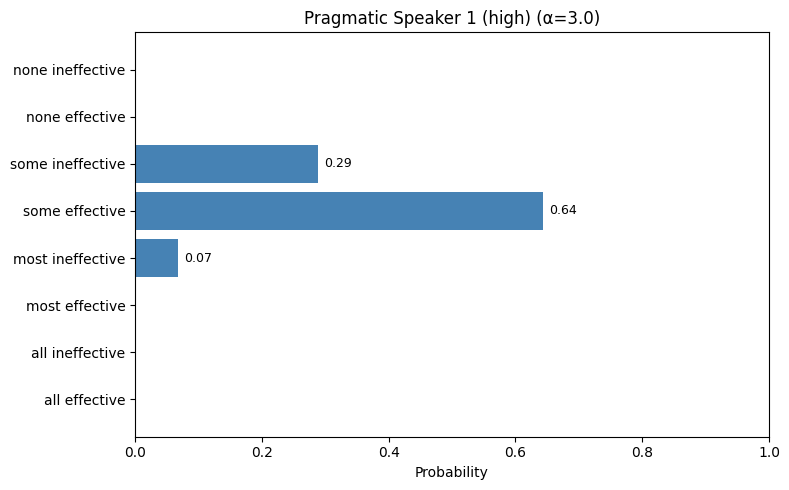


=== speaker 1 high - 7 ===
('none', 'effective'): 0
('none', 'ineffective'): 0
('some', 'effective'): 0.6436
('some', 'ineffective'): 0.2889
('most', 'effective'): 0
('most', 'ineffective'): 0.06745
('all', 'effective'): 0
('all', 'ineffective'): 0

=== speaker 1 inf - 7 ===
('none', 'effective'): 0
('none', 'ineffective'): 0
('some', 'effective'): 0.1391
('some', 'ineffective'): 0.1391
('most', 'effective'): 0
('most', 'ineffective'): 0.7218
('all', 'effective'): 0
('all', 'ineffective'): 0

=== speaker 1 state inf def pers high - 7 ===
('none', 'effective'): 0
('none', 'ineffective'): 0
('some', 'effective'): 0.6436
('some', 'ineffective'): 0.2889
('most', 'effective'): 0
('most', 'ineffective'): 0.06745
('all', 'effective'): 0
('all', 'ineffective'): 0

=== speaker 1 state inf def pers inf - 7 ===
('none', 'effective'): 0
('none', 'ineffective'): 0
('some', 'effective'): 0.09971
('some', 'ineffective'): 0.2013
('most', 'effective'): 0
('most', 'ineffective'): 0.699
('all', 'effecti

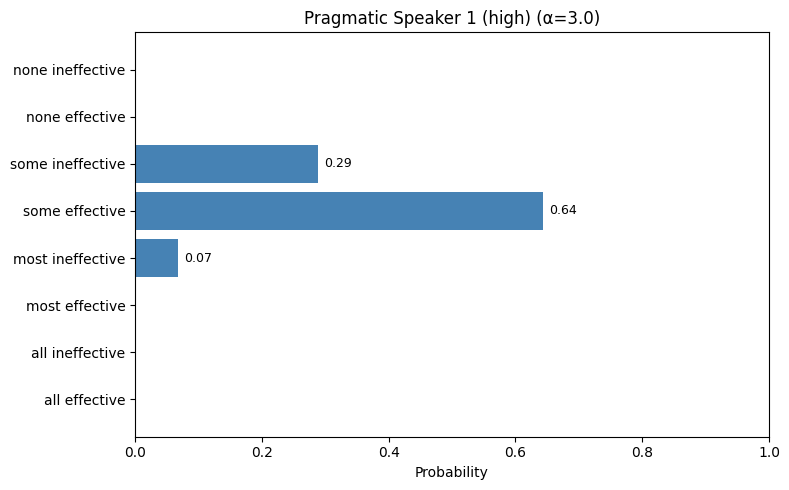

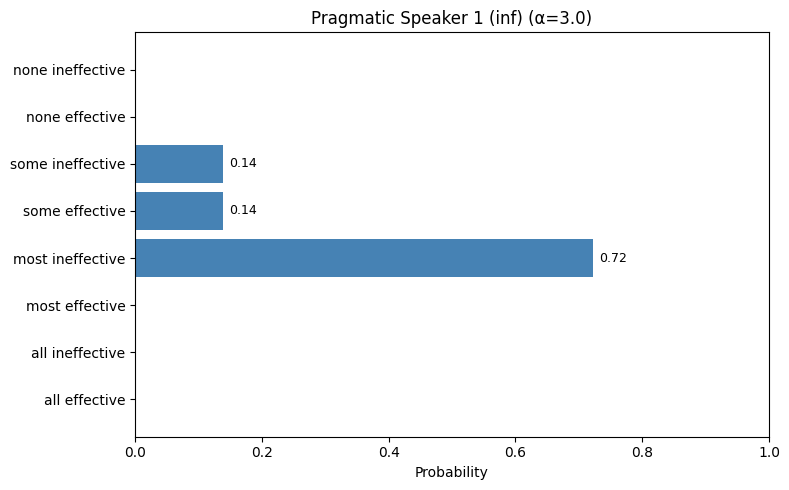


=== speaker 1 high - 7 ===
('none', 'effective'): 0
('none', 'ineffective'): 0
('some', 'effective'): 0.6436
('some', 'ineffective'): 0.2889
('most', 'effective'): 0
('most', 'ineffective'): 0.06745
('all', 'effective'): 0
('all', 'ineffective'): 0

=== speaker 1 inf - 7 ===
('none', 'effective'): 0
('none', 'ineffective'): 0
('some', 'effective'): 0.1391
('some', 'ineffective'): 0.1391
('most', 'effective'): 0
('most', 'ineffective'): 0.7218
('all', 'effective'): 0
('all', 'ineffective'): 0

=== speaker 1 state inf def pers high - 7 ===
('none', 'effective'): 0
('none', 'ineffective'): 0
('some', 'effective'): 0.6436
('some', 'ineffective'): 0.2889
('most', 'effective'): 0
('most', 'ineffective'): 0.06745
('all', 'effective'): 0
('all', 'ineffective'): 0

=== speaker 1 state inf def pers inf - 7 ===
('none', 'effective'): 0
('none', 'ineffective'): 0
('some', 'effective'): 0.09971
('some', 'ineffective'): 0.2013
('most', 'effective'): 0
('most', 'ineffective'): 0.699
('all', 'effecti

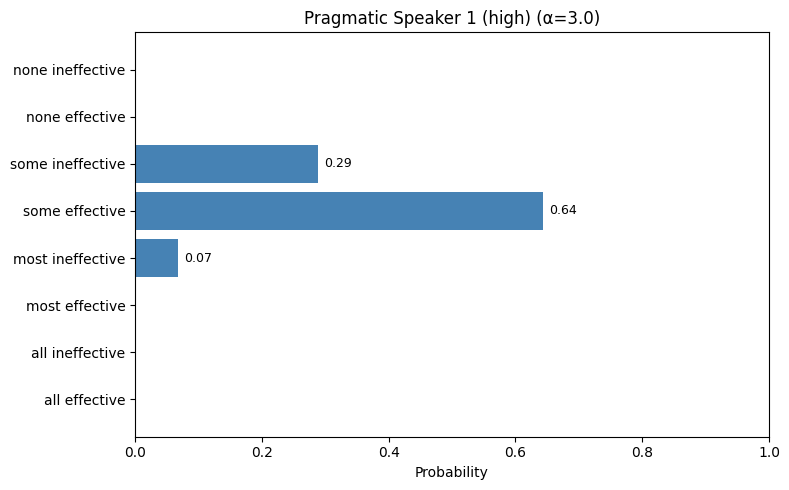

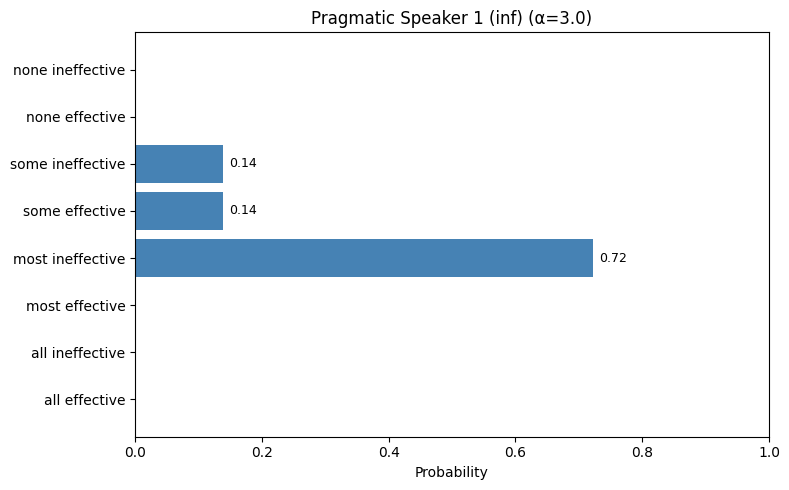

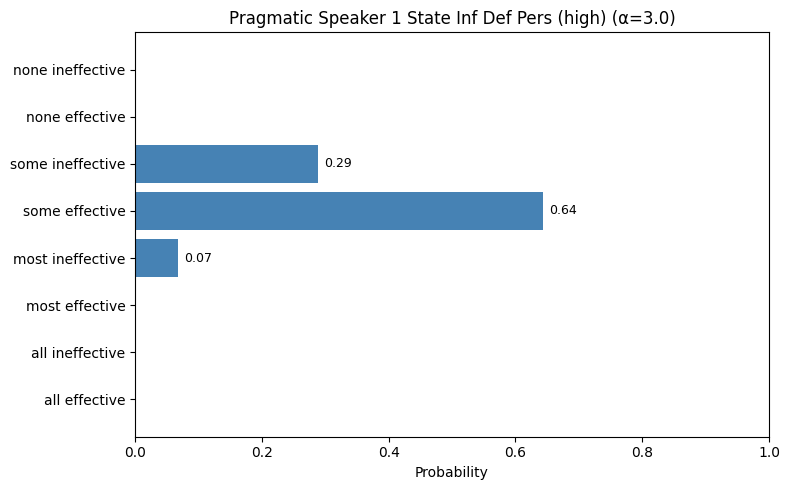


=== speaker 1 high - 7 ===
('none', 'effective'): 0
('none', 'ineffective'): 0
('some', 'effective'): 0.6436
('some', 'ineffective'): 0.2889
('most', 'effective'): 0
('most', 'ineffective'): 0.06745
('all', 'effective'): 0
('all', 'ineffective'): 0

=== speaker 1 inf - 7 ===
('none', 'effective'): 0
('none', 'ineffective'): 0
('some', 'effective'): 0.1391
('some', 'ineffective'): 0.1391
('most', 'effective'): 0
('most', 'ineffective'): 0.7218
('all', 'effective'): 0
('all', 'ineffective'): 0

=== speaker 1 state inf def pers high - 7 ===
('none', 'effective'): 0
('none', 'ineffective'): 0
('some', 'effective'): 0.6436
('some', 'ineffective'): 0.2889
('most', 'effective'): 0
('most', 'ineffective'): 0.06745
('all', 'effective'): 0
('all', 'ineffective'): 0

=== speaker 1 state inf def pers inf - 7 ===
('none', 'effective'): 0
('none', 'ineffective'): 0
('some', 'effective'): 0.09971
('some', 'ineffective'): 0.2013
('most', 'effective'): 0
('most', 'ineffective'): 0.699
('all', 'effecti

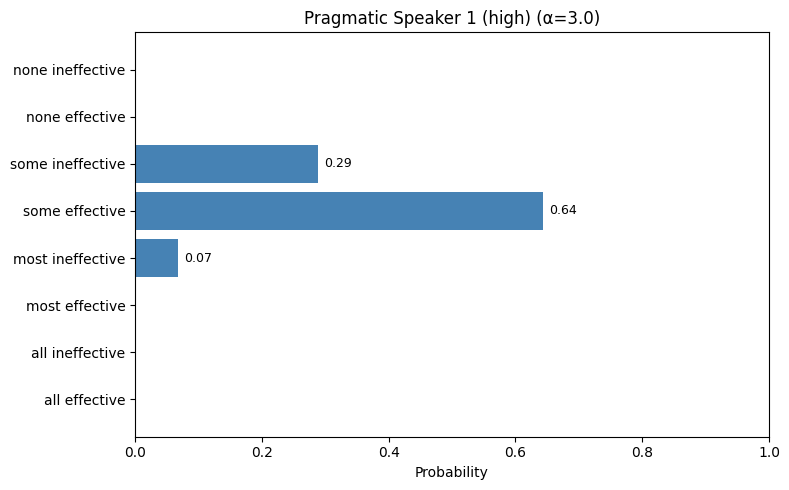

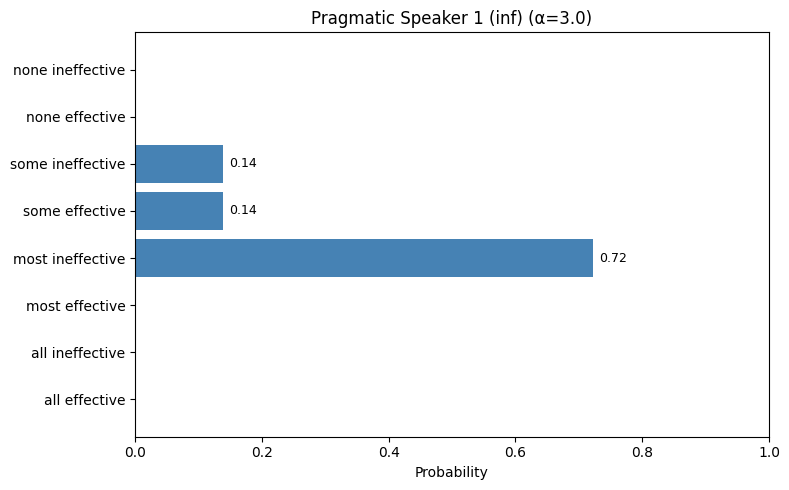

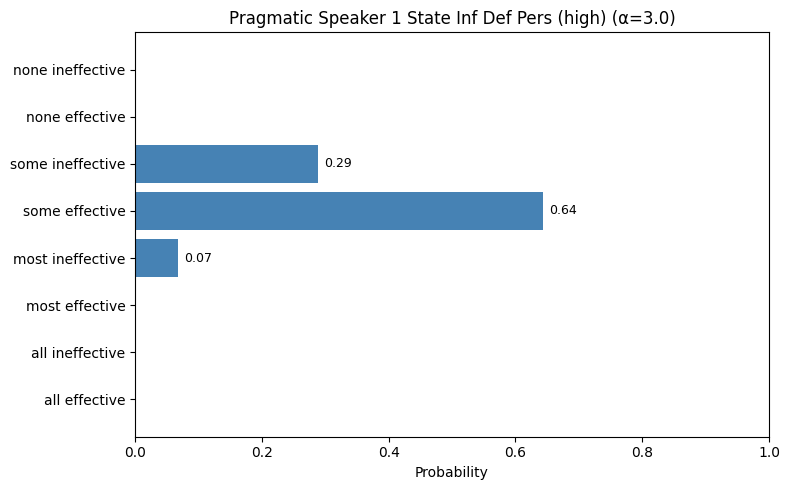

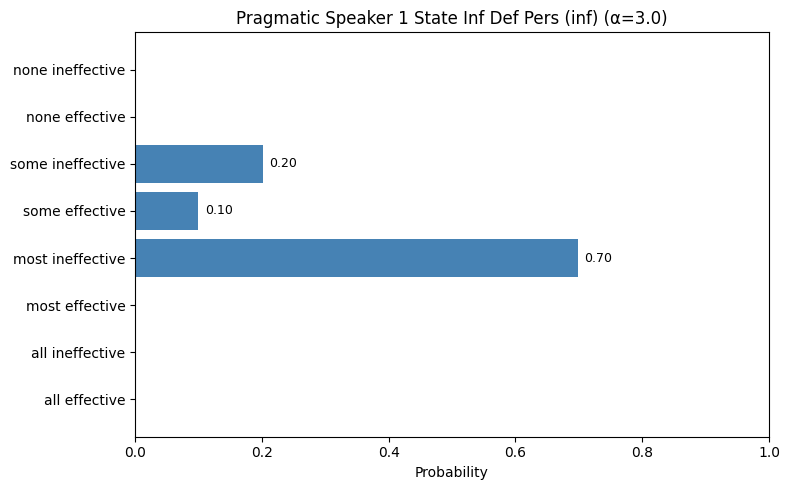


=== speaker 1 high - 7 ===
('none', 'effective'): 0
('none', 'ineffective'): 0
('some', 'effective'): 0.6436
('some', 'ineffective'): 0.2889
('most', 'effective'): 0
('most', 'ineffective'): 0.06745
('all', 'effective'): 0
('all', 'ineffective'): 0

=== speaker 1 inf - 7 ===
('none', 'effective'): 0
('none', 'ineffective'): 0
('some', 'effective'): 0.1391
('some', 'ineffective'): 0.1391
('most', 'effective'): 0
('most', 'ineffective'): 0.7218
('all', 'effective'): 0
('all', 'ineffective'): 0

=== speaker 1 state inf def pers high - 7 ===
('none', 'effective'): 0
('none', 'ineffective'): 0
('some', 'effective'): 0.6436
('some', 'ineffective'): 0.2889
('most', 'effective'): 0
('most', 'ineffective'): 0.06745
('all', 'effective'): 0
('all', 'ineffective'): 0

=== speaker 1 state inf def pers inf - 7 ===
('none', 'effective'): 0
('none', 'ineffective'): 0
('some', 'effective'): 0.09971
('some', 'ineffective'): 0.2013
('most', 'effective'): 0
('most', 'ineffective'): 0.699
('all', 'effecti

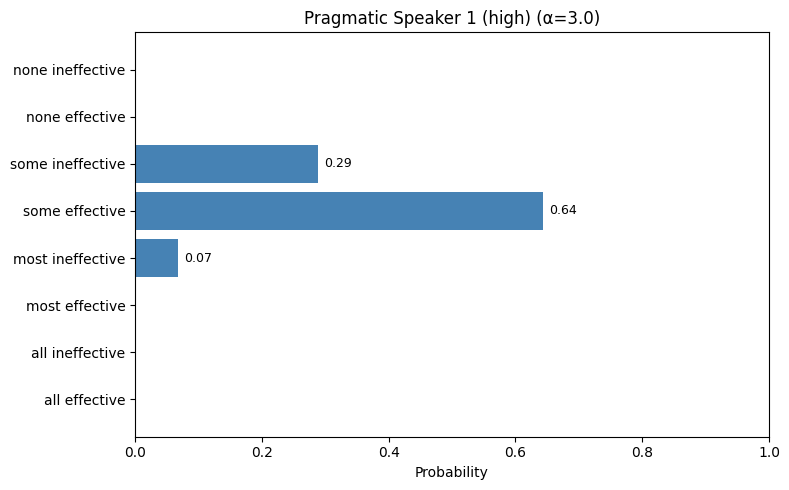

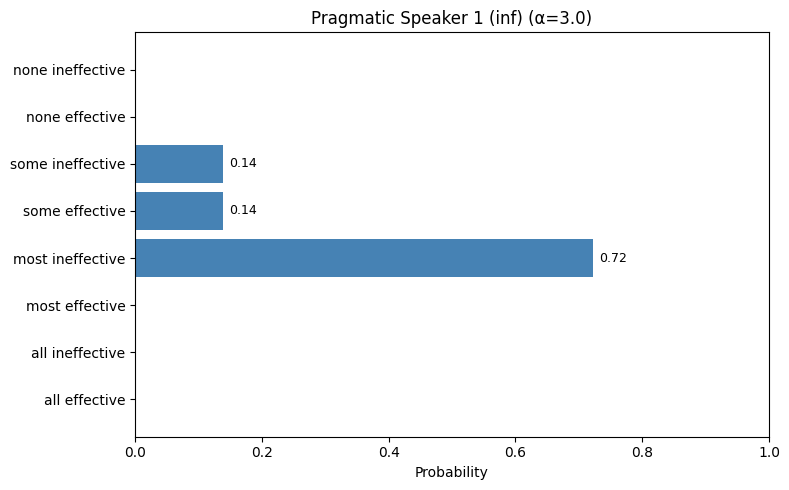

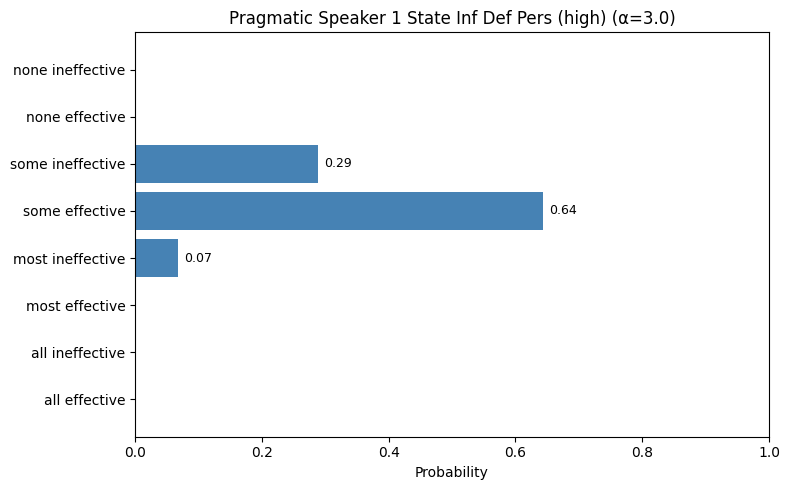

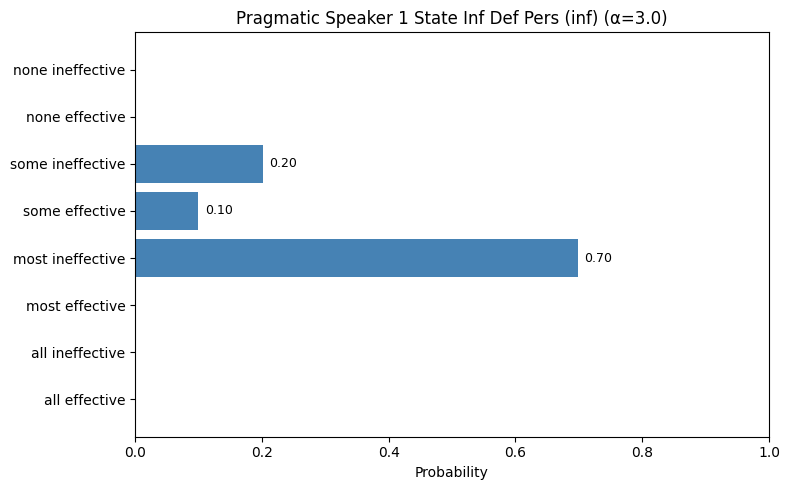

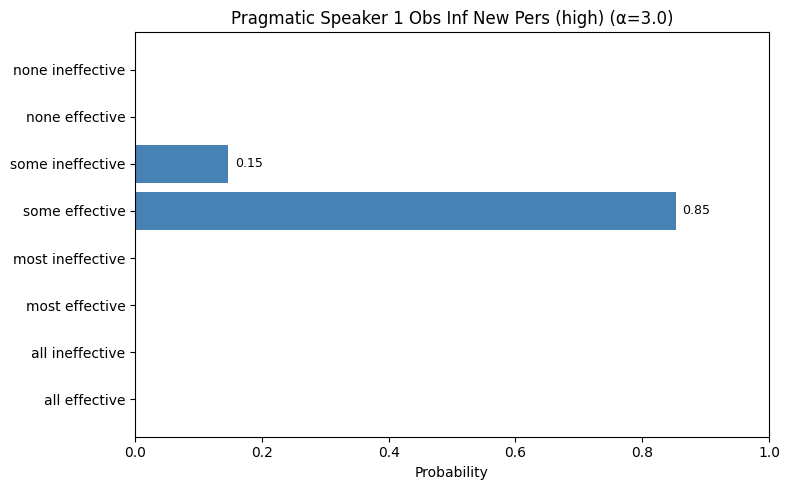


=== speaker 1 high - 7 ===
('none', 'effective'): 0
('none', 'ineffective'): 0
('some', 'effective'): 0.6436
('some', 'ineffective'): 0.2889
('most', 'effective'): 0
('most', 'ineffective'): 0.06745
('all', 'effective'): 0
('all', 'ineffective'): 0

=== speaker 1 inf - 7 ===
('none', 'effective'): 0
('none', 'ineffective'): 0
('some', 'effective'): 0.1391
('some', 'ineffective'): 0.1391
('most', 'effective'): 0
('most', 'ineffective'): 0.7218
('all', 'effective'): 0
('all', 'ineffective'): 0

=== speaker 1 state inf def pers high - 7 ===
('none', 'effective'): 0
('none', 'ineffective'): 0
('some', 'effective'): 0.6436
('some', 'ineffective'): 0.2889
('most', 'effective'): 0
('most', 'ineffective'): 0.06745
('all', 'effective'): 0
('all', 'ineffective'): 0

=== speaker 1 state inf def pers inf - 7 ===
('none', 'effective'): 0
('none', 'ineffective'): 0
('some', 'effective'): 0.09971
('some', 'ineffective'): 0.2013
('most', 'effective'): 0
('most', 'ineffective'): 0.699
('all', 'effecti

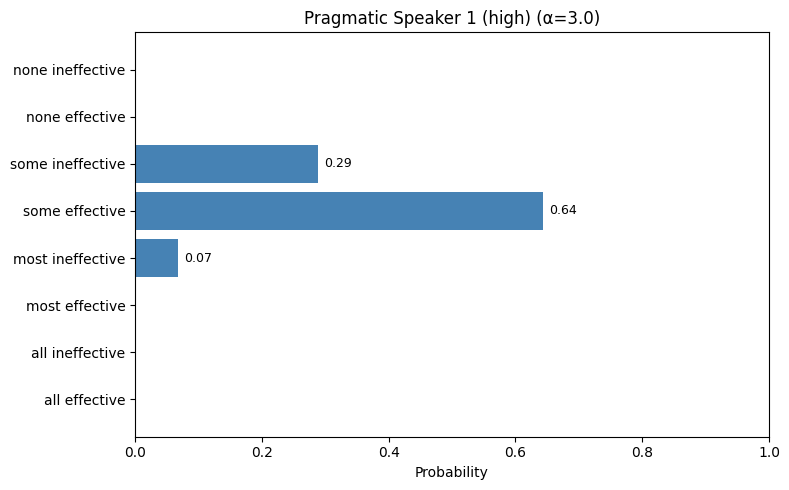

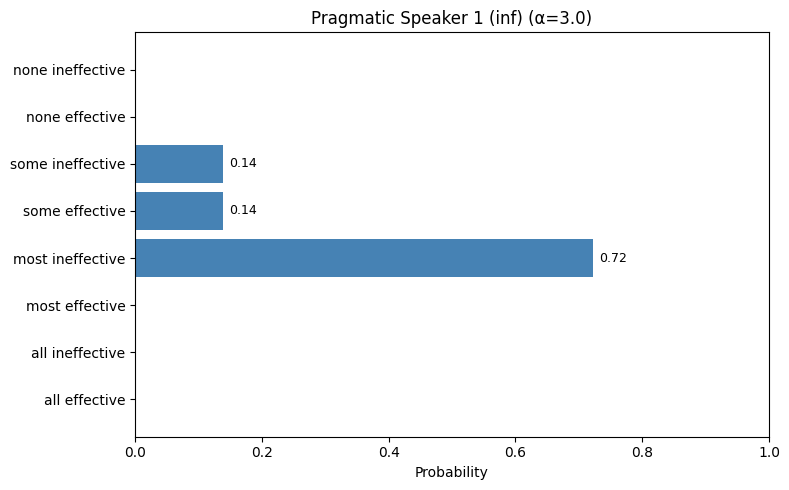

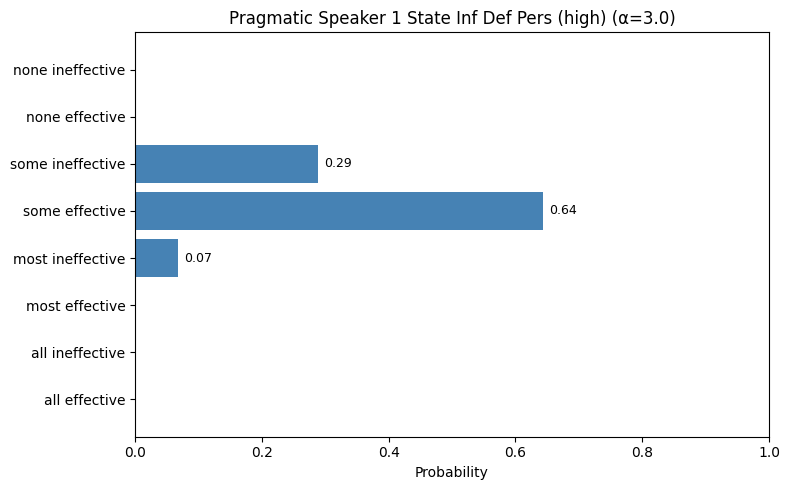

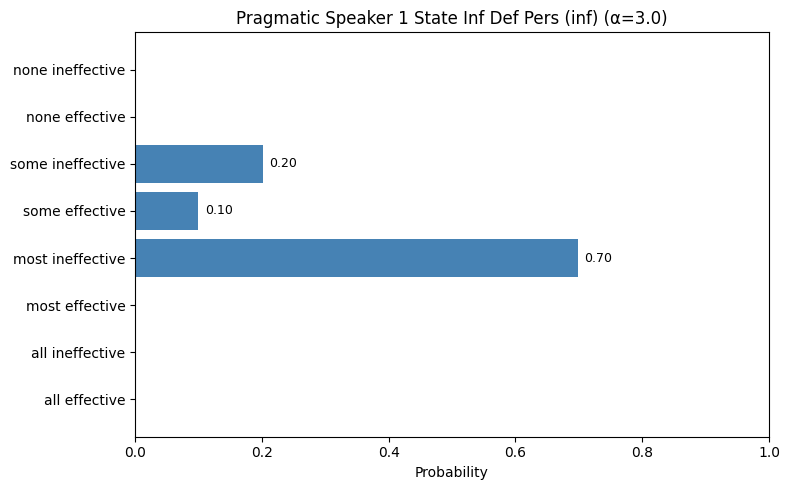

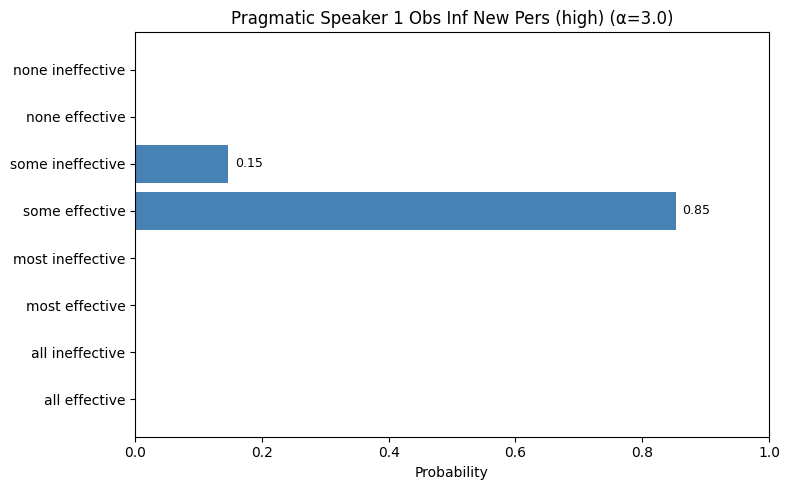

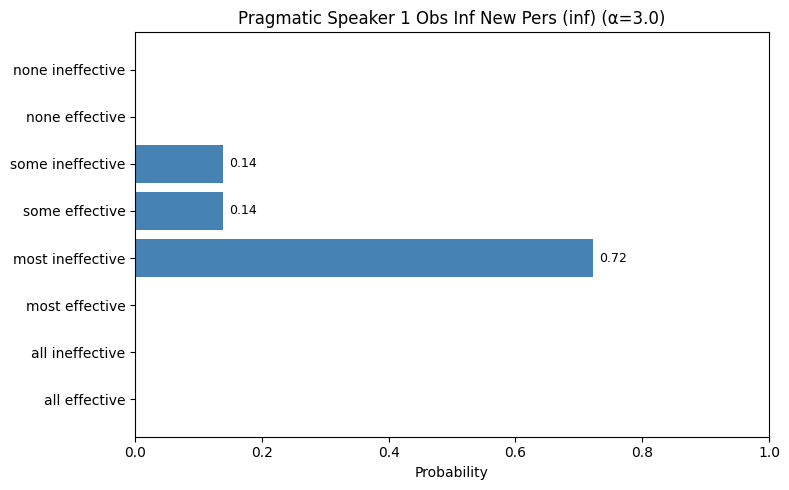


=== speaker 1 high - 7 ===
('none', 'effective'): 0
('none', 'ineffective'): 0
('some', 'effective'): 0.6436
('some', 'ineffective'): 0.2889
('most', 'effective'): 0
('most', 'ineffective'): 0.06745
('all', 'effective'): 0
('all', 'ineffective'): 0

=== speaker 1 inf - 7 ===
('none', 'effective'): 0
('none', 'ineffective'): 0
('some', 'effective'): 0.1391
('some', 'ineffective'): 0.1391
('most', 'effective'): 0
('most', 'ineffective'): 0.7218
('all', 'effective'): 0
('all', 'ineffective'): 0

=== speaker 1 state inf def pers high - 7 ===
('none', 'effective'): 0
('none', 'ineffective'): 0
('some', 'effective'): 0.6436
('some', 'ineffective'): 0.2889
('most', 'effective'): 0
('most', 'ineffective'): 0.06745
('all', 'effective'): 0
('all', 'ineffective'): 0

=== speaker 1 state inf def pers inf - 7 ===
('none', 'effective'): 0
('none', 'ineffective'): 0
('some', 'effective'): 0.09971
('some', 'ineffective'): 0.2013
('most', 'effective'): 0
('most', 'ineffective'): 0.699
('all', 'effecti

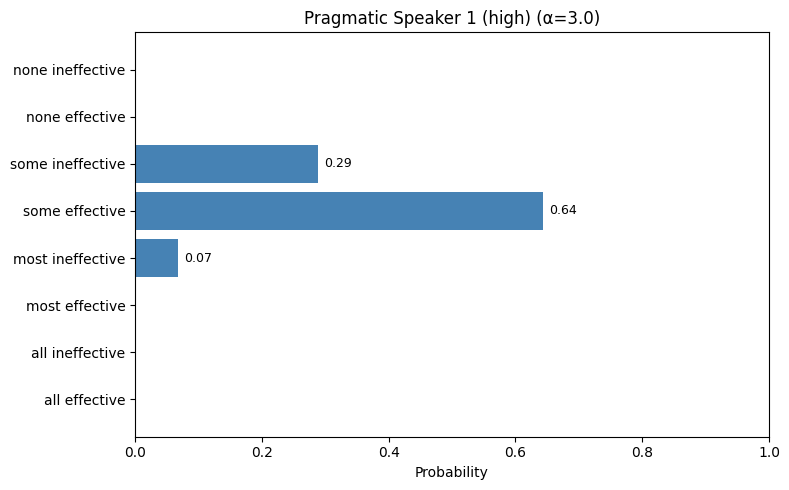

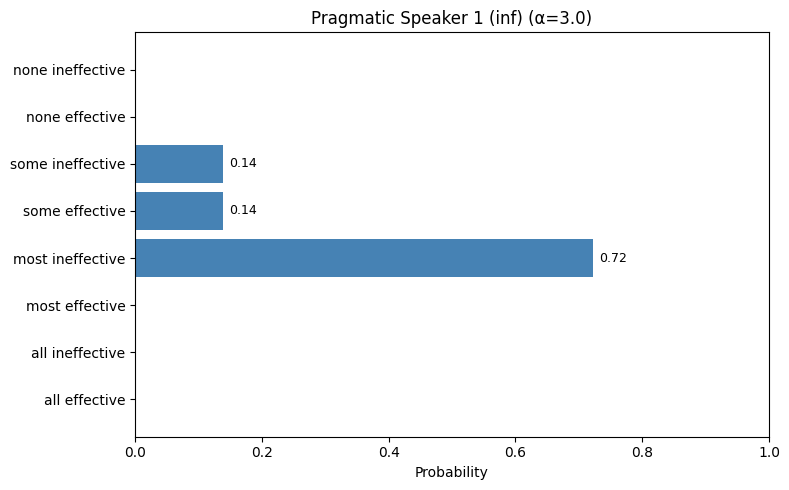

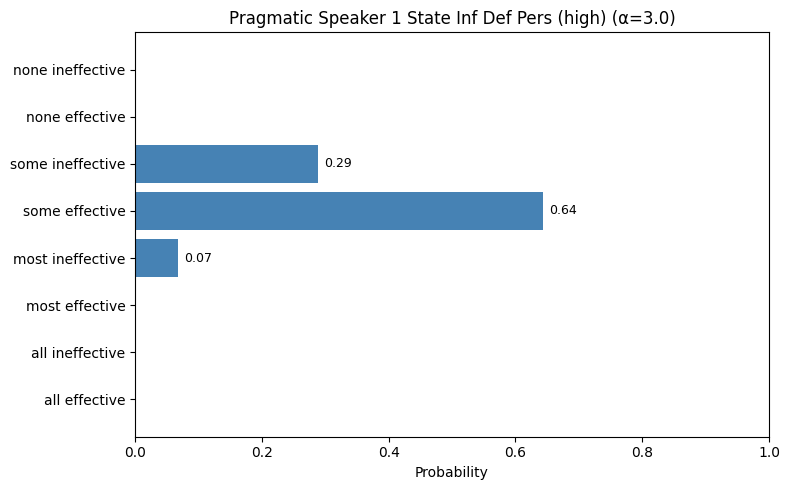

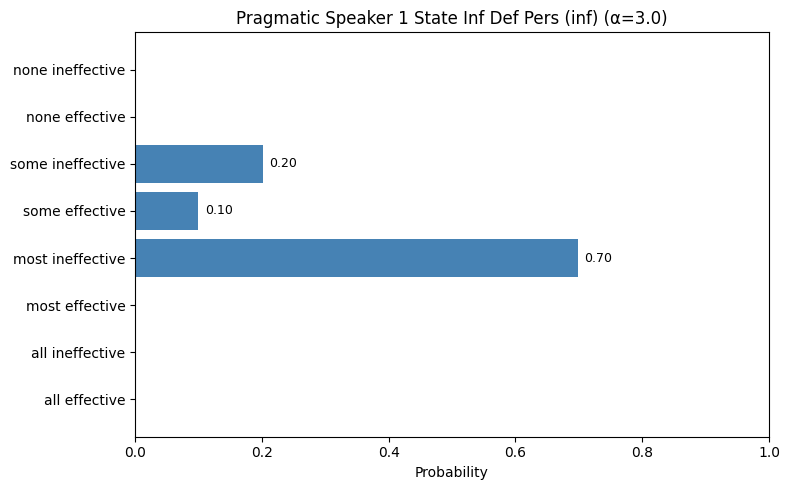

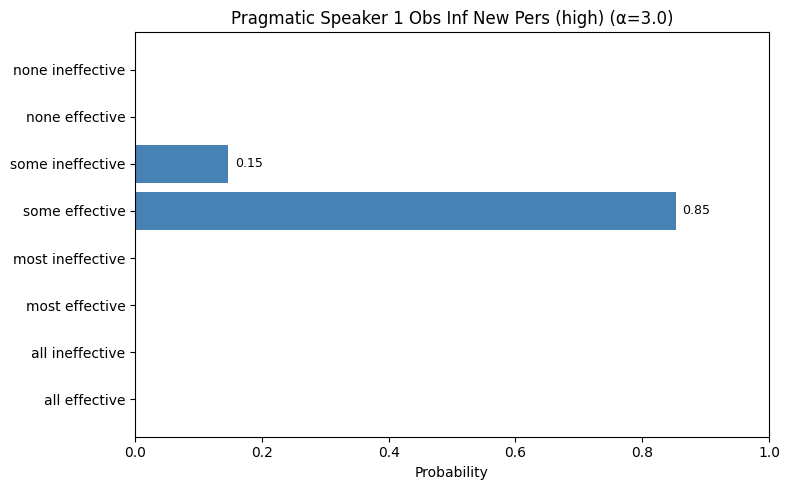

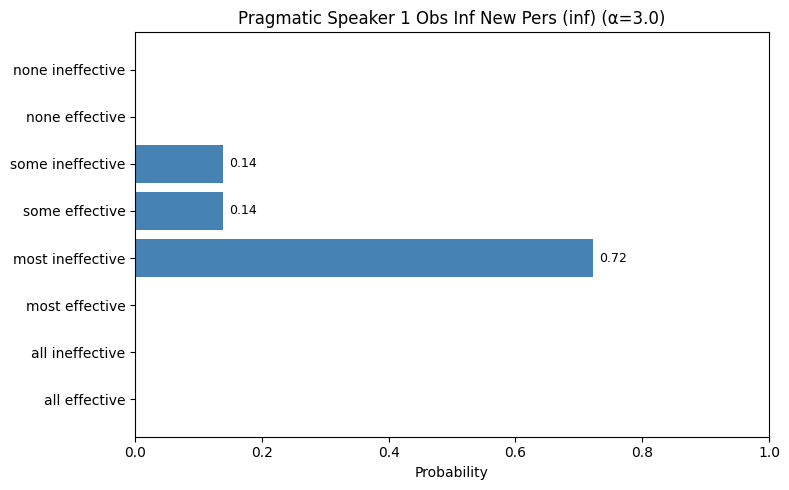

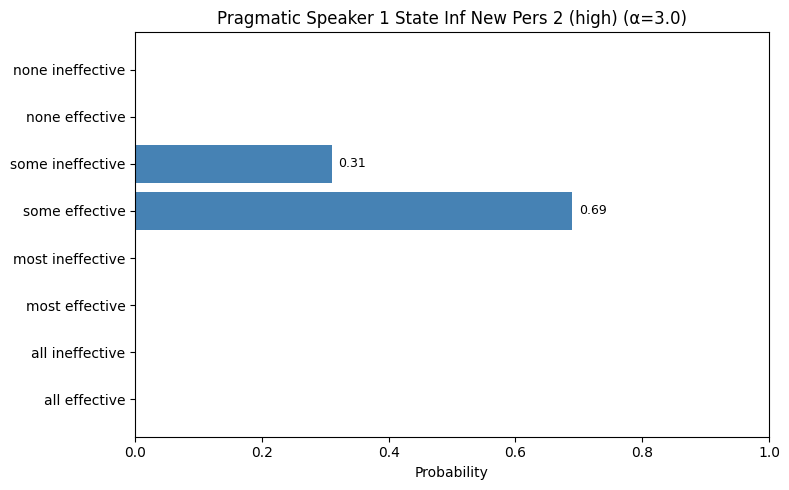


=== speaker 1 high - 7 ===
('none', 'effective'): 0
('none', 'ineffective'): 0
('some', 'effective'): 0.6436
('some', 'ineffective'): 0.2889
('most', 'effective'): 0
('most', 'ineffective'): 0.06745
('all', 'effective'): 0
('all', 'ineffective'): 0

=== speaker 1 inf - 7 ===
('none', 'effective'): 0
('none', 'ineffective'): 0
('some', 'effective'): 0.1391
('some', 'ineffective'): 0.1391
('most', 'effective'): 0
('most', 'ineffective'): 0.7218
('all', 'effective'): 0
('all', 'ineffective'): 0

=== speaker 1 state inf def pers high - 7 ===
('none', 'effective'): 0
('none', 'ineffective'): 0
('some', 'effective'): 0.6436
('some', 'ineffective'): 0.2889
('most', 'effective'): 0
('most', 'ineffective'): 0.06745
('all', 'effective'): 0
('all', 'ineffective'): 0

=== speaker 1 state inf def pers inf - 7 ===
('none', 'effective'): 0
('none', 'ineffective'): 0
('some', 'effective'): 0.09971
('some', 'ineffective'): 0.2013
('most', 'effective'): 0
('most', 'ineffective'): 0.699
('all', 'effecti

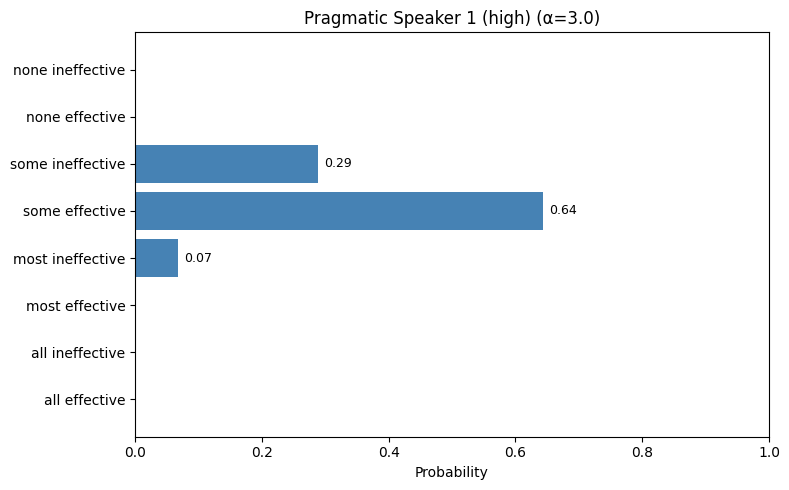

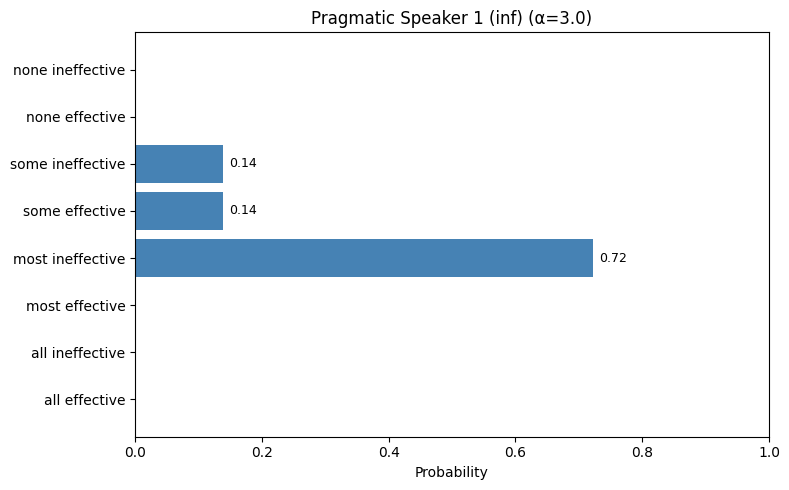

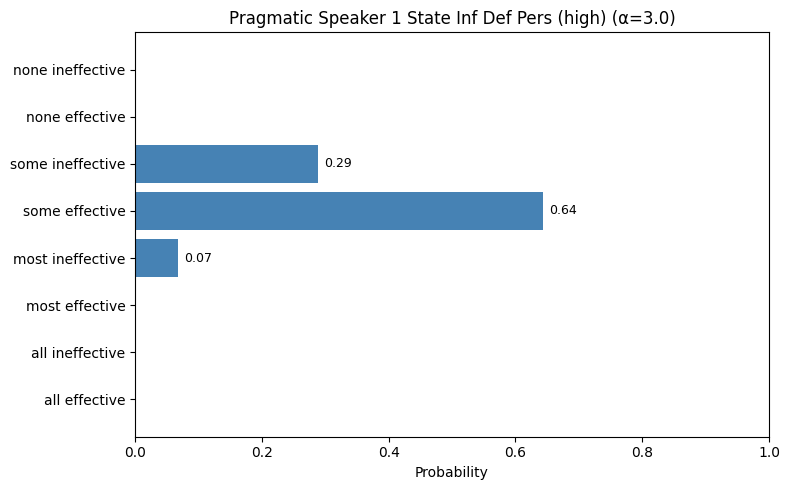

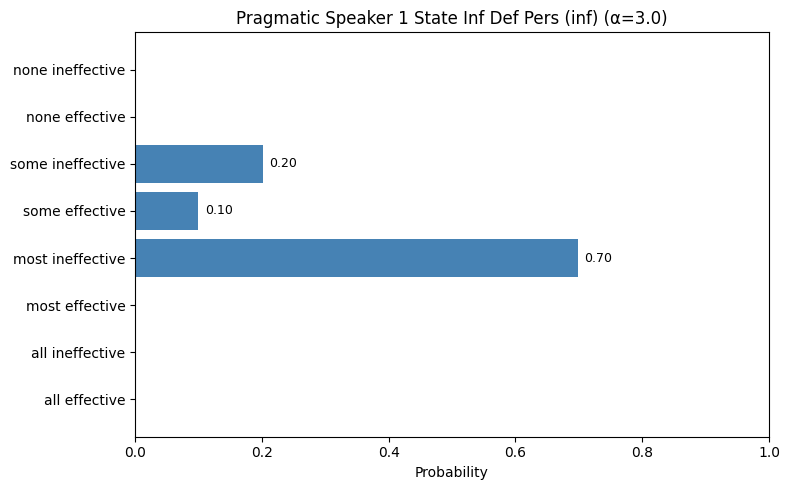

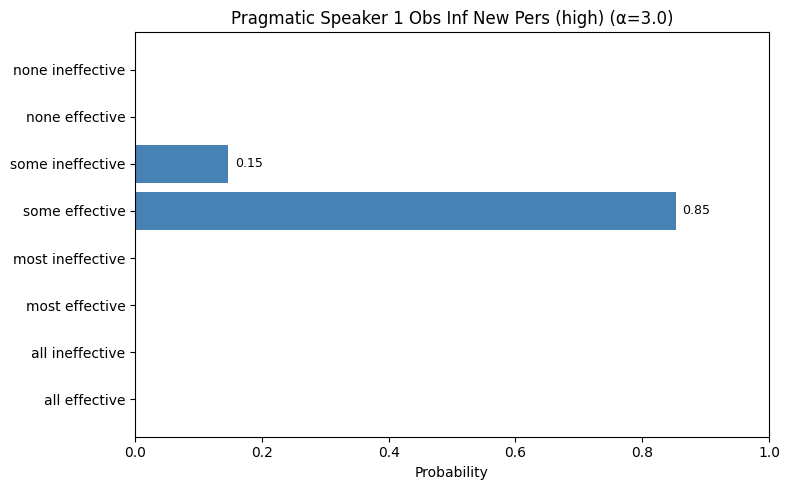

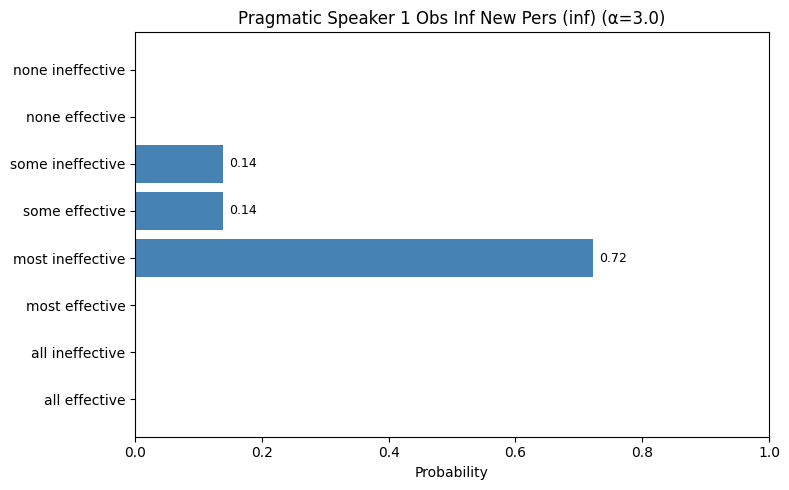

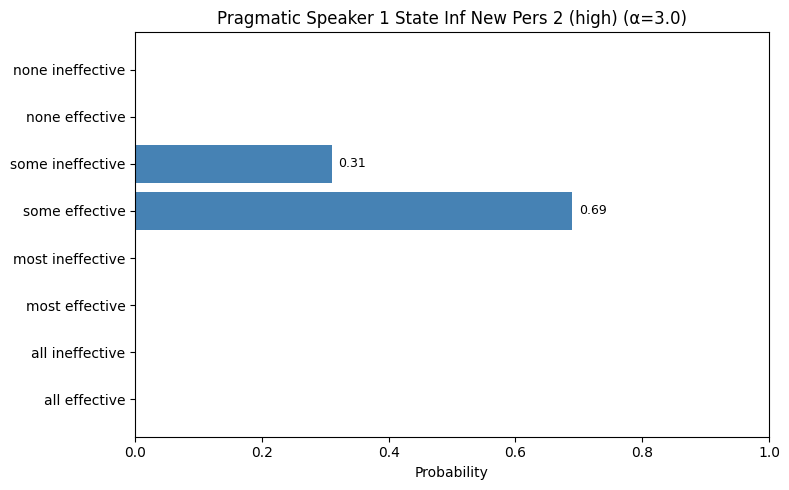

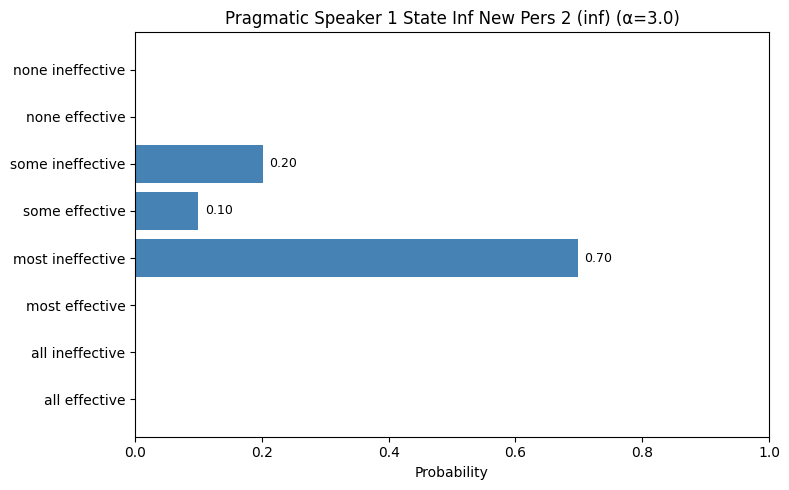


=== speaker 1 high - 7 ===
('none', 'effective'): 0
('none', 'ineffective'): 0
('some', 'effective'): 0.6436
('some', 'ineffective'): 0.2889
('most', 'effective'): 0
('most', 'ineffective'): 0.06745
('all', 'effective'): 0
('all', 'ineffective'): 0

=== speaker 1 inf - 7 ===
('none', 'effective'): 0
('none', 'ineffective'): 0
('some', 'effective'): 0.1391
('some', 'ineffective'): 0.1391
('most', 'effective'): 0
('most', 'ineffective'): 0.7218
('all', 'effective'): 0
('all', 'ineffective'): 0

=== speaker 1 state inf def pers high - 7 ===
('none', 'effective'): 0
('none', 'ineffective'): 0
('some', 'effective'): 0.6436
('some', 'ineffective'): 0.2889
('most', 'effective'): 0
('most', 'ineffective'): 0.06745
('all', 'effective'): 0
('all', 'ineffective'): 0

=== speaker 1 state inf def pers inf - 7 ===
('none', 'effective'): 0
('none', 'ineffective'): 0
('some', 'effective'): 0.09971
('some', 'ineffective'): 0.2013
('most', 'effective'): 0
('most', 'ineffective'): 0.699
('all', 'effecti

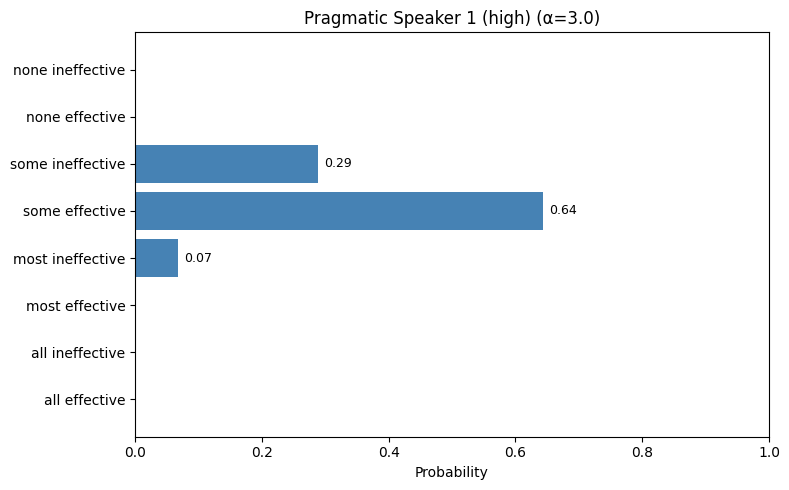

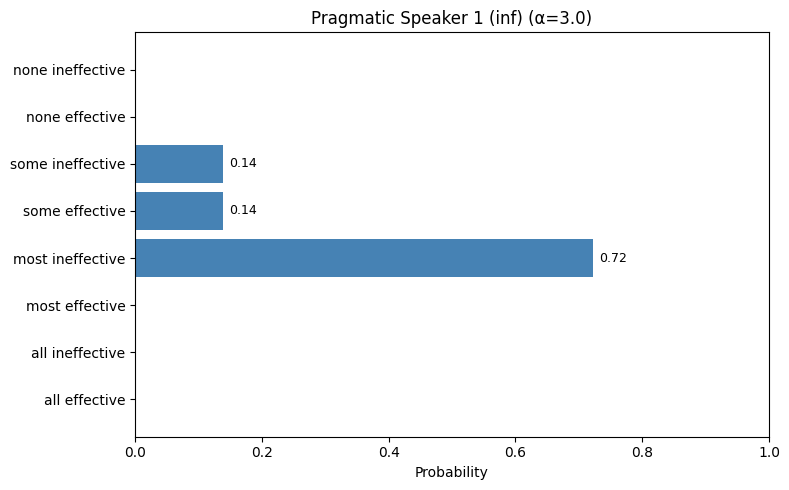

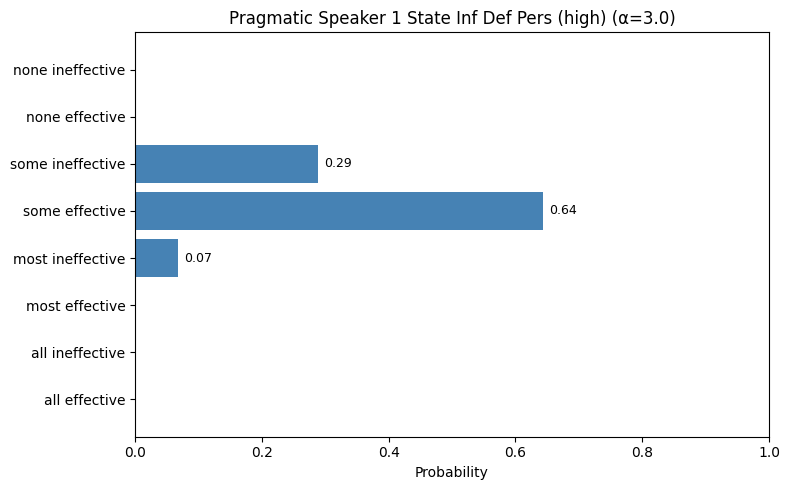

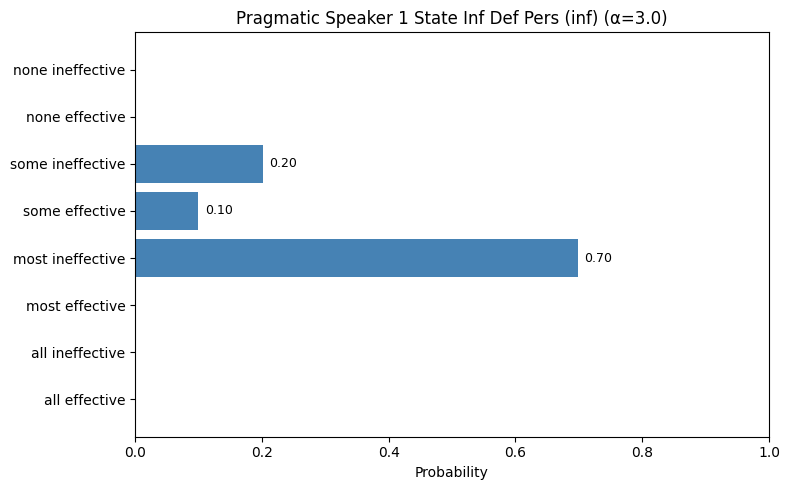

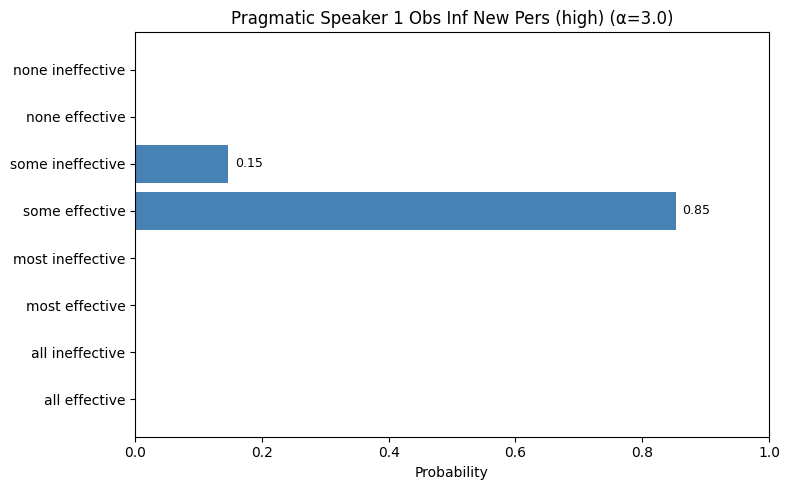

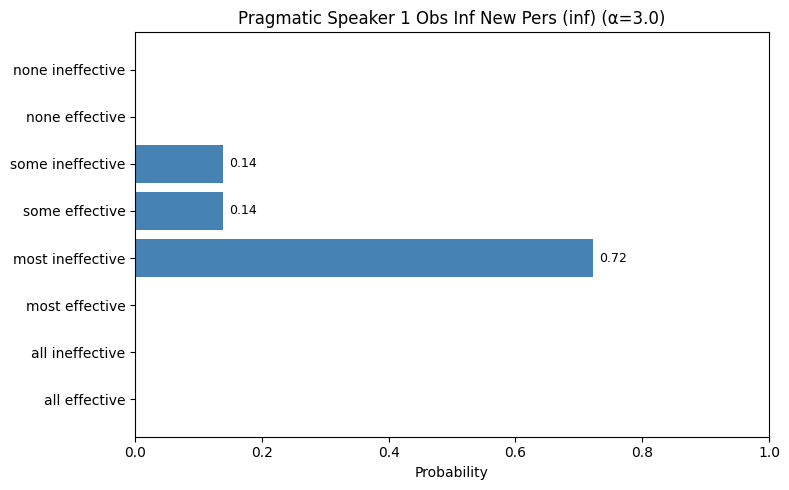

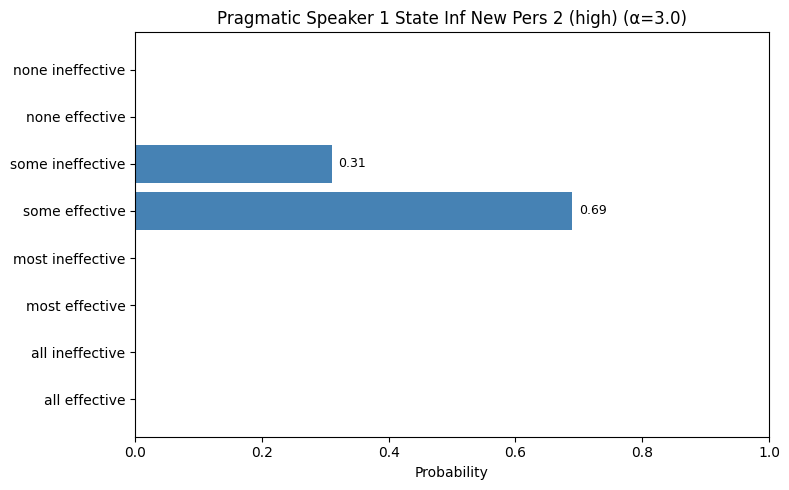

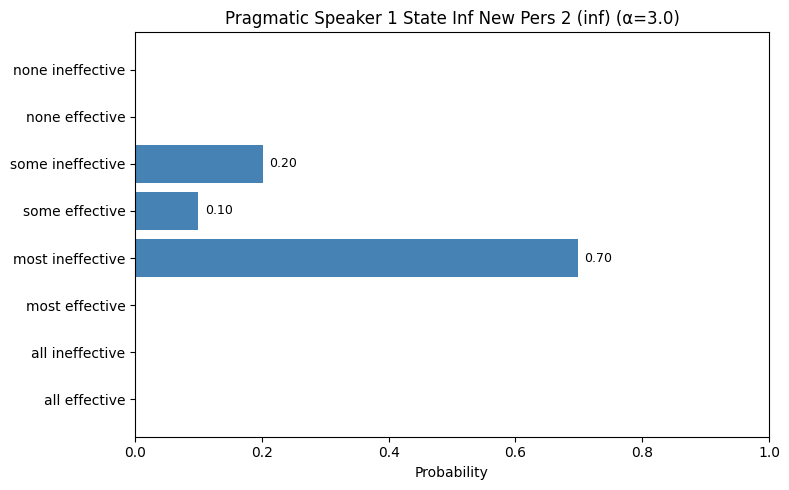

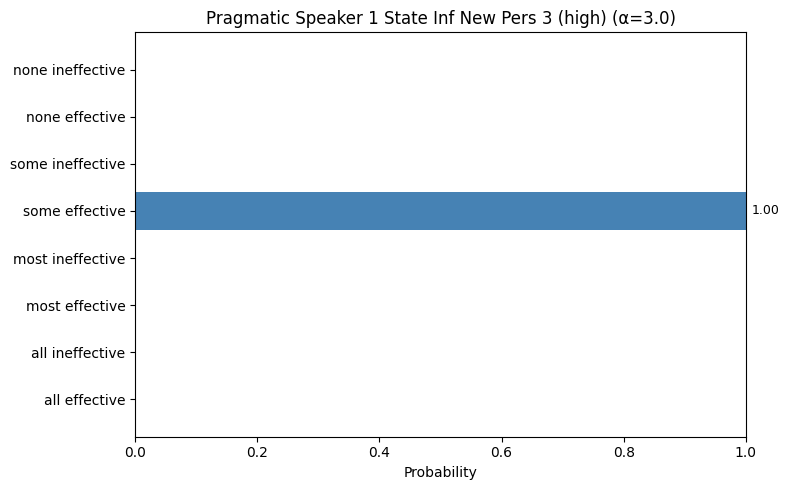


=== speaker 1 high - 7 ===
('none', 'effective'): 0
('none', 'ineffective'): 0
('some', 'effective'): 0.6436
('some', 'ineffective'): 0.2889
('most', 'effective'): 0
('most', 'ineffective'): 0.06745
('all', 'effective'): 0
('all', 'ineffective'): 0

=== speaker 1 inf - 7 ===
('none', 'effective'): 0
('none', 'ineffective'): 0
('some', 'effective'): 0.1391
('some', 'ineffective'): 0.1391
('most', 'effective'): 0
('most', 'ineffective'): 0.7218
('all', 'effective'): 0
('all', 'ineffective'): 0

=== speaker 1 state inf def pers high - 7 ===
('none', 'effective'): 0
('none', 'ineffective'): 0
('some', 'effective'): 0.6436
('some', 'ineffective'): 0.2889
('most', 'effective'): 0
('most', 'ineffective'): 0.06745
('all', 'effective'): 0
('all', 'ineffective'): 0

=== speaker 1 state inf def pers inf - 7 ===
('none', 'effective'): 0
('none', 'ineffective'): 0
('some', 'effective'): 0.09971
('some', 'ineffective'): 0.2013
('most', 'effective'): 0
('most', 'ineffective'): 0.699
('all', 'effecti

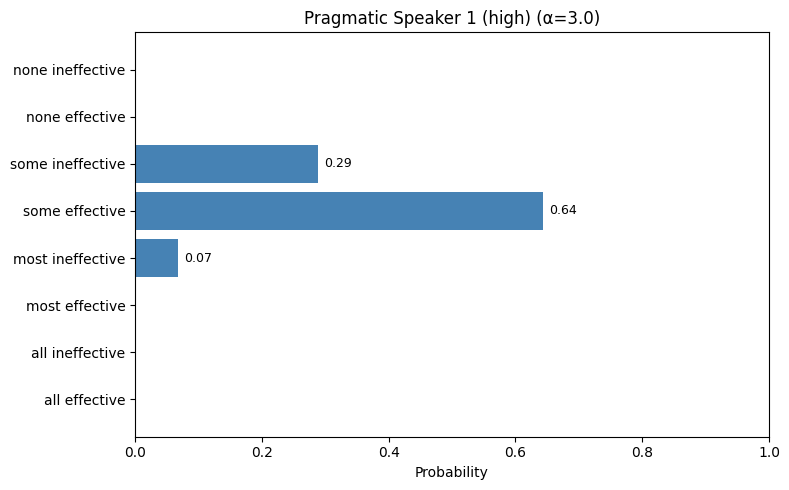

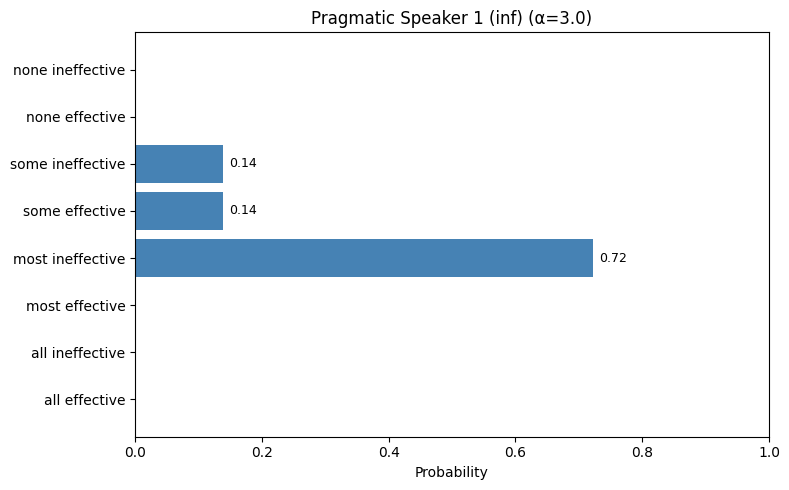

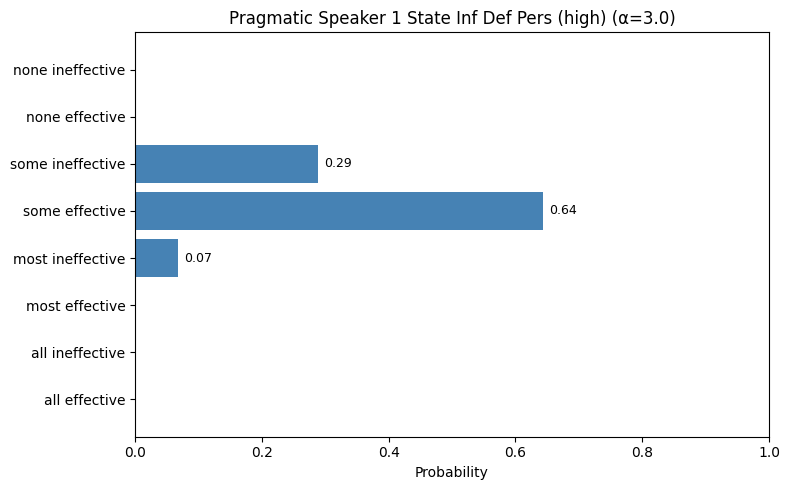

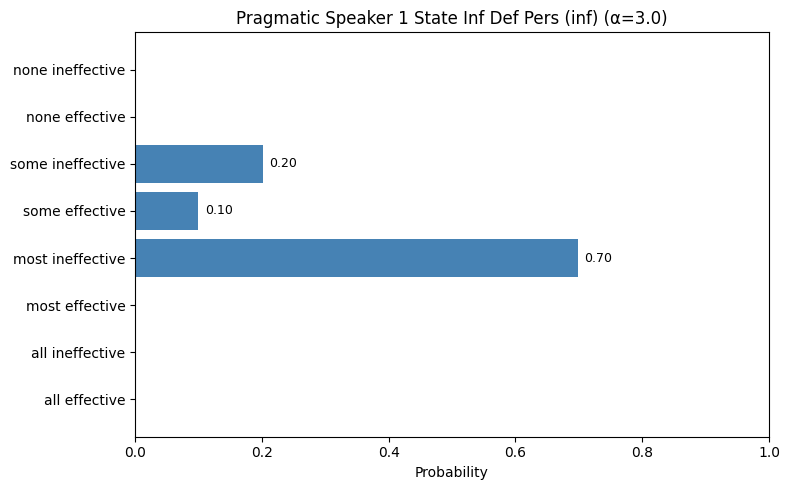

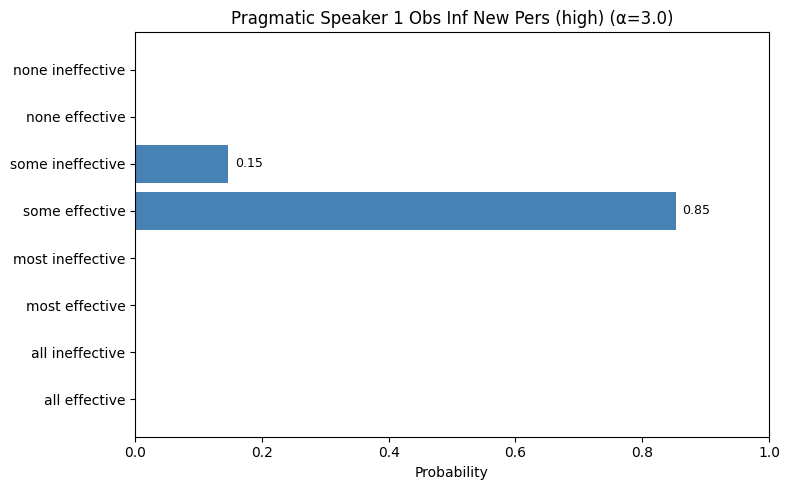

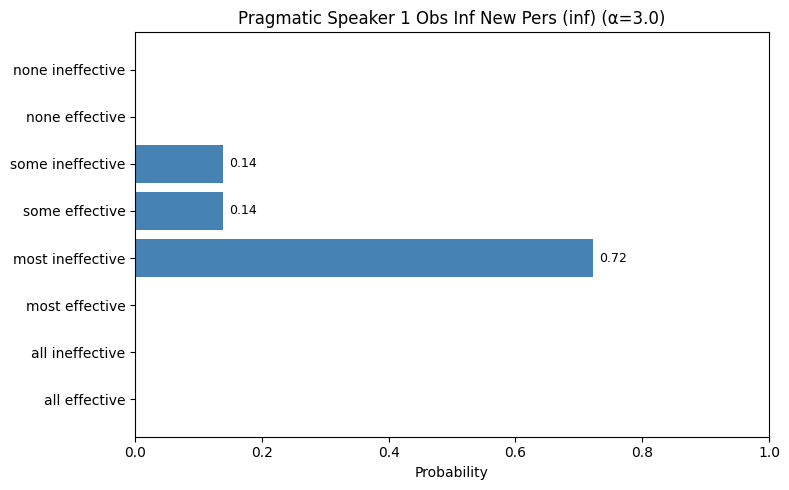

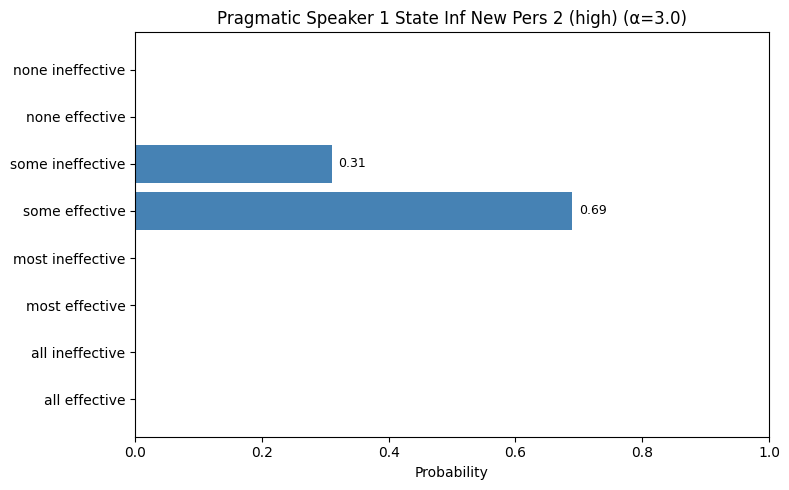

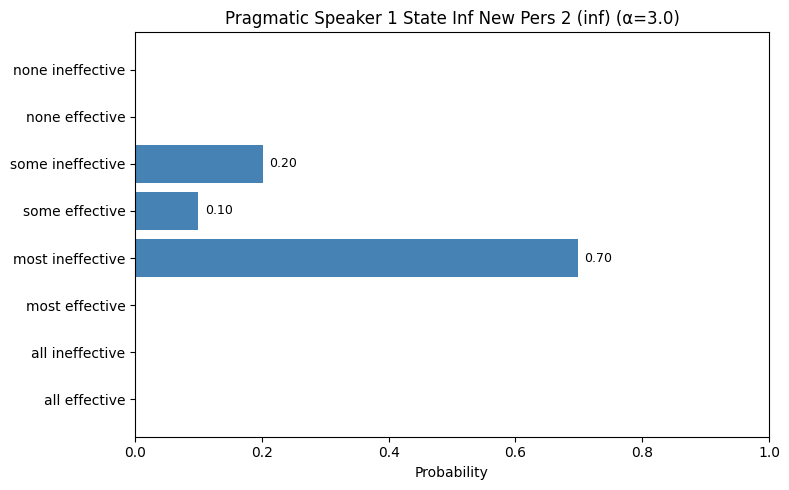

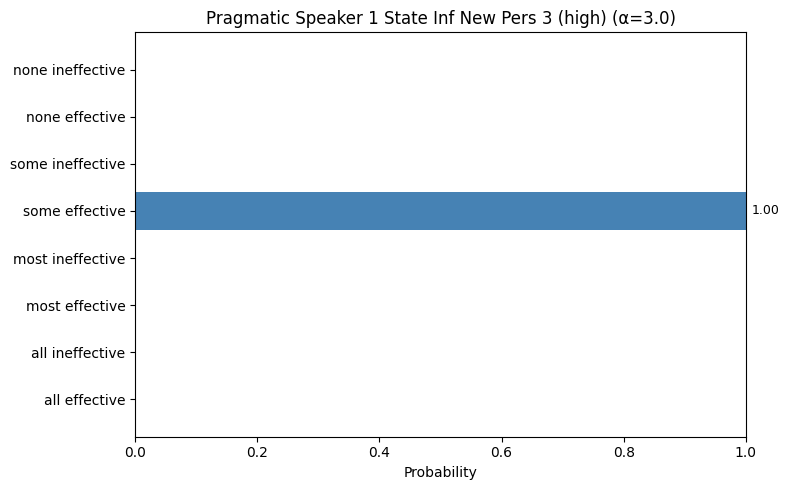

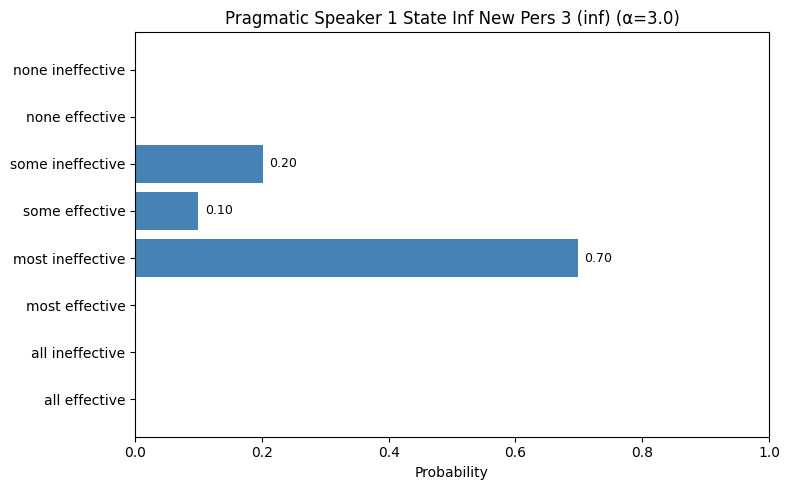

In [ ]:
from itertools import product
theta = 0.3
thetas = [0.1 * i for i in range(0, 11)]
psis = ["inf", "high"]
world_parameters = {"n": 1, "m": 7}
alpha = 1.0
speaker_type = "high"
listener_type = "inf"
threshold = 0.9

world = World(theta, world_parameters, get_obs_prob, generate_all_observations)
quantifiers = ["none", "some", "most", "all"]
predicates = ["effective", "ineffective"]
if world_parameters["n"] > 1:
    utterances = list(product(quantifiers, quantifiers, predicates))
else:
    utterances = list(product(quantifiers, predicates))

# utterances.append(("all", "none"))
semantics = Semantics(utterances, utterance_is_true)

literal_speaker = Speaker0(thetas, semantics=semantics, world=world)
literal_listener = Listener0(thetas, literal_speaker, semantics=semantics, world=world)
pragmatic_speaker_1_obs_inf_def_pers = Speaker1(thetas, literal_listener, semantics=semantics, world=world, alpha=alpha, psi=speaker_type)
pragmatic_speaker_1_state_inf_def_pers = Speaker1_state_inf_def_pers(thetas, literal_listener, semantics=semantics, world=world, alpha=alpha, psi=speaker_type)
pragmatic_speaker_1_obs_inf_new_pers = Speaker1_obs_inf_new_pers1(thetas, literal_listener, semantics=semantics, world=world, alpha=alpha, psi=speaker_type)
pragmatic_speaker_1_state_inf_new_pers = Speaker1_state_inf_new_pers1(thetas, literal_listener, semantics=semantics, world=world, alpha=alpha, psi=speaker_type)
pragmatic_speaker_1_state_inf_new_pers2 = Speaker1_state_inf_new_pers3(thetas, literal_listener, semantics=semantics, world=world, alpha=alpha, psi=speaker_type)
pragmatic_speaker_1_state_inf_new_pers3 = Speaker1_state_inf_new_pers3(thetas, literal_listener, semantics=semantics, world=world, alpha=alpha, psi=speaker_type)
pragmatic_speaker_1_state_inf_new_pers4 = Speaker1_state_inf_new_pers4(thetas, literal_listener, semantics=semantics, world=world, alpha=alpha, psi=speaker_type)
pragmatic_speaker_1_state_inf_pers_bayes = Speaker1_state_inf_pers_bayes(thetas, literal_listener, semantics=semantics, world=world, alpha=alpha, psi=speaker_type)

# Create pragmatic listeners for each speaker type (with listener_type="inf")
pragmatic_listener_1_obs_inf_def_pers_inf = Listener1(thetas, psis, pragmatic_speaker_1_obs_inf_def_pers, world, semantics, listener_type="inf", alpha=alpha)
pragmatic_listener_1_state_inf_def_pers_inf = Listener1(thetas, psis, pragmatic_speaker_1_state_inf_def_pers, world, semantics, listener_type="inf", alpha=alpha)
pragmatic_listener_1_obs_inf_new_pers_inf = Listener1(thetas, psis, pragmatic_speaker_1_obs_inf_new_pers, world, semantics, listener_type="inf", alpha=alpha)
pragmatic_listener_1_state_inf_new_pers_inf = Listener1(thetas, psis, pragmatic_speaker_1_state_inf_new_pers, world, semantics, listener_type="inf", alpha=alpha)
pragmatic_listener_1_state_inf_new_pers2_inf = Listener1(thetas, psis, pragmatic_speaker_1_state_inf_new_pers2, world, semantics, listener_type="inf", alpha=alpha)
pragmatic_listener_1_state_inf_new_pers3_inf = Listener1(thetas, psis, pragmatic_speaker_1_state_inf_new_pers3, world, semantics, listener_type="inf", alpha=alpha)
pragmatic_listener_1_state_inf_new_pers4_inf = Listener1(thetas, psis, pragmatic_speaker_1_state_inf_new_pers4, world, semantics, listener_type="inf", alpha=alpha)
pragmatic_listener_1_state_inf_pers_bayes_inf = Listener1(thetas, psis, pragmatic_speaker_1_state_inf_pers_bayes, world, semantics, listener_type="inf", alpha=alpha)

# Create pragmatic listeners for each speaker type (with listener_type="vig")
pragmatic_listener_1_obs_inf_def_pers_vig = Listener1(thetas, psis, pragmatic_speaker_1_obs_inf_def_pers, world, semantics, listener_type="vig", alpha=alpha)
pragmatic_listener_1_state_inf_def_pers_vig = Listener1(thetas, psis, pragmatic_speaker_1_state_inf_def_pers, world, semantics, listener_type="vig", alpha=alpha)
pragmatic_listener_1_obs_inf_new_pers_vig = Listener1(thetas, psis, pragmatic_speaker_1_obs_inf_new_pers, world, semantics, listener_type="vig", alpha=alpha)
pragmatic_listener_1_state_inf_new_pers_vig = Listener1(thetas, psis, pragmatic_speaker_1_state_inf_new_pers, world, semantics, listener_type="vig", alpha=alpha)
pragmatic_listener_1_state_inf_new_pers2_vig = Listener1(thetas, psis, pragmatic_speaker_1_state_inf_new_pers2, world, semantics, listener_type="vig", alpha=alpha)
pragmatic_listener_1_state_inf_new_pers3_vig = Listener1(thetas, psis, pragmatic_speaker_1_state_inf_new_pers3, world, semantics, listener_type="vig", alpha=alpha)
pragmatic_listener_1_state_inf_new_pers4_vig = Listener1(thetas, psis, pragmatic_speaker_1_state_inf_new_pers4, world, semantics, listener_type="vig", alpha=alpha)
pragmatic_listener_1_state_inf_pers_bayes_vig = Listener1(thetas, psis, pragmatic_speaker_1_state_inf_pers_bayes, world, semantics, listener_type="vig", alpha=alpha)


obs = (0,0,0,0,0,0,0,1)

# Calculate distributions once
obs_inf_def_pers_high = pragmatic_speaker_1_obs_inf_def_pers.dist_over_utterances_obs(obs, "high")
obs_inf_def_pers_inf = pragmatic_speaker_1_obs_inf_def_pers.dist_over_utterances_obs(obs, "inf")

state_inf_def_pers_high = pragmatic_speaker_1_state_inf_def_pers.dist_over_utterances_obs(obs, "high")
state_inf_def_pers_inf = pragmatic_speaker_1_state_inf_def_pers.dist_over_utterances_obs(obs, "inf")

obs_inf_new_pers_high = pragmatic_speaker_1_obs_inf_new_pers.dist_over_utterances_obs(obs, "high")
obs_inf_new_pers_inf = pragmatic_speaker_1_obs_inf_new_pers.dist_over_utterances_obs(obs, "inf")

state_inf_new_pers_high = pragmatic_speaker_1_state_inf_new_pers.dist_over_utterances_obs(obs, "high")
state_inf_new_pers_inf = pragmatic_speaker_1_state_inf_new_pers.dist_over_utterances_obs(obs, "inf")

state_inf_new_pers2_high = pragmatic_speaker_1_state_inf_new_pers2.dist_over_utterances_obs(obs, "high")
state_inf_new_pers2_inf = pragmatic_speaker_1_state_inf_new_pers2.dist_over_utterances_obs(obs, "inf")

state_inf_new_pers3_high = pragmatic_speaker_1_state_inf_new_pers3.dist_over_utterances_obs(obs, "high")
state_inf_new_pers3_inf = pragmatic_speaker_1_state_inf_new_pers3.dist_over_utterances_obs(obs, "inf")

state_inf_new_pers4_high = pragmatic_speaker_1_state_inf_new_pers4.dist_over_utterances_obs(obs, "high")
state_inf_new_pers4_inf = pragmatic_speaker_1_state_inf_new_pers4.dist_over_utterances_obs(obs, "inf")

state_inf_pers_bayes_mean_high = pragmatic_speaker_1_state_inf_pers_bayes.dist_over_utterances_obs(obs, "high", bayes = "mean")
state_inf_pers_bayes_mean_inf = pragmatic_speaker_1_state_inf_pers_bayes.dist_over_utterances_obs(obs, "inf", bayes = "mean")

state_inf_pers_bayes_median_high = pragmatic_speaker_1_state_inf_pers_bayes.dist_over_utterances_obs(obs, "high", bayes = "median")
state_inf_pers_bayes_median_inf = pragmatic_speaker_1_state_inf_pers_bayes.dist_over_utterances_obs(obs, "inf", bayes = "median")

print(pragmatic_speaker_1_state_inf_new_pers.get_persuasiveness("high", obs))

# Print
pretty_print("speaker 1 high - 7", obs_inf_def_pers_high)
pretty_print("speaker 1 inf - 7", obs_inf_def_pers_inf)

pretty_print("speaker 1 state inf def pers high - 7", state_inf_def_pers_high)
pretty_print("speaker 1 state inf def pers inf - 7", state_inf_def_pers_inf)

pretty_print("speaker 1 obs inf new pers high - 7", obs_inf_new_pers_high)
pretty_print("speaker 1 obs inf new pers inf - 7", obs_inf_new_pers_inf)

pretty_print("speaker 1 state inf new pers high - 7", state_inf_new_pers_high)
pretty_print("speaker 1 state inf new pers inf - 7", state_inf_new_pers_inf)

pretty_print("speaker 1 state inf new pers2 high - 7", state_inf_new_pers2_high)
pretty_print("speaker 1 state inf new pers2 inf - 7", state_inf_new_pers2_inf)

pretty_print("speaker 1 state inf new pers3 high - 7", state_inf_new_pers3_high)
pretty_print("speaker 1 state inf new pers3 inf - 7", state_inf_new_pers3_inf)

pretty_print("speaker 1 state inf new pers4 high - 7", state_inf_new_pers4_high)
pretty_print("speaker 1 state inf new pers4 inf - 7", state_inf_new_pers4_inf)

# Plot
plot_speaker_distribution(obs_inf_def_pers_high, title="Pragmatic Speaker 1 (high)", alpha=alpha)
plot_speaker_distribution(obs_inf_def_pers_inf, title="Pragmatic Speaker 1 (inf)", alpha=alpha)

plot_speaker_distribution(state_inf_def_pers_high, title="Pragmatic Speaker 1 State Inf Def Pers (high)", alpha=alpha)
plot_speaker_distribution(state_inf_def_pers_inf, title="Pragmatic Speaker 1 State Inf Def Pers (inf)", alpha=alpha)

plot_speaker_distribution(obs_inf_new_pers_high, title="Pragmatic Speaker 1 Obs Inf New Pers (high)", alpha=alpha)
plot_speaker_distribution(obs_inf_new_pers_inf, title="Pragmatic Speaker 1 Obs Inf New Pers (inf)", alpha=alpha)

plot_speaker_distribution(state_inf_new_pers_high, title="Pragmatic Speaker 1 State Inf New Pers (high)", alpha=alpha)
plot_speaker_distribution(state_inf_new_pers_inf, title="Pragmatic Speaker 1 State Inf New Pers (inf)", alpha=alpha)

plot_speaker_distribution(state_inf_new_pers2_high, title="Pragmatic Speaker 1 State Inf New Pers 2 (high)", alpha=alpha)
plot_speaker_distribution(state_inf_new_pers2_inf, title="Pragmatic Speaker 1 State Inf New Pers 2 (inf)", alpha=alpha)

plot_speaker_distribution(state_inf_new_pers3_high, title="Pragmatic Speaker 1 State Inf New Pers 3 (high)", alpha=alpha)
plot_speaker_distribution(state_inf_new_pers3_inf, title="Pragmatic Speaker 1 State Inf New Pers 3 (inf)", alpha=alpha)

plot_speaker_distribution(state_inf_new_pers4_high, title="Pragmatic Speaker 1 State Inf New Pers 4 (high)", alpha=alpha)
plot_speaker_distribution(state_inf_new_pers4_inf, title="Pragmatic Speaker 1 State Inf New Pers 4 (inf)", alpha=alpha)

def find_mean(theta_dist):
    mean = 0
    for theta, prob in theta_dist.items():
        mean += theta * prob
    return mean

#discrete theta_dist
def find_median(theta_dist):
    sorted_thetas = sorted(theta_dist.items())
    cumulative_prob = 0.0
    prev_theta = sorted_thetas[0][0]
    for theta, prob in sorted_thetas:
        cumulative_prob += prob
        if cumulative_prob == 0.5:
            return theta
        if cumulative_prob > 0.5:
            return ((prev_theta) + theta ) / 2
    return sorted_thetas[-1][0]  # Return the highest theta if not found earlier

def find_pers_result(speaker_probs, listener):
    pers_result = 0
    for utt, prob in speaker_probs.items():
        pers_result += find_mean(listener.infer_state(utt).marginal(0)) * prob
    return pers_result

def find_pers_type_result(speaker_probs, listener):
    pers_result = 0
    for utt, prob in speaker_probs.items():
        pers_result += find_mean(listener.infer_state(utt).marginal(1)) * prob
    return pers_result

# Calculate persuasiveness results for each speaker type with literal listener
print("\n=== Persuasiveness Results with Literal Listener ===")
pers_obs_inf_def_pers_high_L0 = find_pers_result(obs_inf_def_pers_high, literal_listener)
pers_obs_inf_def_pers_inf_L0 = find_pers_result(obs_inf_def_pers_inf, literal_listener)
print(f"Obs Inf Def Pers (high) - L0: {pers_obs_inf_def_pers_high_L0:.4f}")
print(f"Obs Inf Def Pers (inf) - L0: {pers_obs_inf_def_pers_inf_L0:.4f}")

pers_state_inf_def_pers_high_L0 = find_pers_result(state_inf_def_pers_high, literal_listener)
pers_state_inf_def_pers_inf_L0 = find_pers_result(state_inf_def_pers_inf, literal_listener)
print(f"State Inf Def Pers (high) - L0: {pers_state_inf_def_pers_high_L0:.4f}")
print(f"State Inf Def Pers (inf) - L0: {pers_state_inf_def_pers_inf_L0:.4f}")

pers_obs_inf_new_pers_high_L0 = find_pers_result(obs_inf_new_pers_high, literal_listener)
pers_obs_inf_new_pers_inf_L0 = find_pers_result(obs_inf_new_pers_inf, literal_listener)
print(f"Obs Inf New Pers (high) - L0: {pers_obs_inf_new_pers_high_L0:.4f}")
print(f"Obs Inf New Pers (inf) - L0: {pers_obs_inf_new_pers_inf_L0:.4f}")

pers_state_inf_new_pers_high_L0 = find_pers_result(state_inf_new_pers_high, literal_listener)
pers_state_inf_new_pers_inf_L0 = find_pers_result(state_inf_new_pers_inf, literal_listener)
print(f"State Inf New Pers (high) - L0: {pers_state_inf_new_pers_high_L0:.4f}")
print(f"State Inf New Pers (inf) - L0: {pers_state_inf_new_pers_inf_L0:.4f}")

pers_state_inf_new_pers2_high_L0 = find_pers_result(state_inf_new_pers2_high, literal_listener)
pers_state_inf_new_pers2_inf_L0 = find_pers_result(state_inf_new_pers2_inf, literal_listener)
print(f"State Inf New Pers2 (high) - L0: {pers_state_inf_new_pers2_high_L0:.4f}")
print(f"State Inf New Pers2 (inf) - L0: {pers_state_inf_new_pers2_inf_L0:.4f}")

pers_state_inf_new_pers3_high_L0 = find_pers_result(state_inf_new_pers3_high, literal_listener)
pers_state_inf_new_pers3_inf_L0 = find_pers_result(state_inf_new_pers3_inf, literal_listener)
print(f"State Inf New Pers3 (high) - L0: {pers_state_inf_new_pers3_high_L0:.4f}")
print(f"State Inf New Pers3 (inf) - L0: {pers_state_inf_new_pers3_inf_L0:.4f}")

pers_state_inf_new_pers4_high_L0 = find_pers_result(state_inf_new_pers4_high, literal_listener)
pers_state_inf_new_pers4_inf_L0 = find_pers_result(state_inf_new_pers4_inf, literal_listener)
print(f"State Inf New Pers4 (high) - L0: {pers_state_inf_new_pers4_high_L0:.4f}")
print(f"State Inf New Pers4 (inf) - L0: {pers_state_inf_new_pers4_inf_L0:.4f}")

# Calculate persuasiveness results for each speaker type with pragmatic listener (inf)
print("\n=== Persuasiveness Results with Pragmatic Listener 1 (inf) ===")
pers_obs_inf_def_pers_high_L1_inf = find_pers_result(obs_inf_def_pers_high, pragmatic_listener_1_obs_inf_def_pers_inf)
pers_obs_inf_def_pers_inf_L1_inf = find_pers_result(obs_inf_def_pers_inf, pragmatic_listener_1_obs_inf_def_pers_inf)
print(f"Obs Inf Def Pers (high) - L1_inf: {pers_obs_inf_def_pers_high_L1_inf:.4f}")
print(f"Obs Inf Def Pers (inf) - L1_inf: {pers_obs_inf_def_pers_inf_L1_inf:.4f}")

pers_state_inf_def_pers_inf_L1_inf = find_pers_result(state_inf_def_pers_inf, pragmatic_listener_1_state_inf_def_pers_inf)
pers_state_inf_def_pers_high_L1_inf = find_pers_result(state_inf_def_pers_high, pragmatic_listener_1_state_inf_def_pers_inf)
print(f"State Inf Def Pers (high) - L1_inf: {pers_state_inf_def_pers_high_L1_inf:.4f}")
print(f"State Inf Def Pers (inf) - L1_inf: {pers_state_inf_def_pers_inf_L1_inf:.4f}")

pers_obs_inf_new_pers_inf_L1_inf = find_pers_result(obs_inf_new_pers_inf, pragmatic_listener_1_obs_inf_new_pers_inf)
pers_obs_inf_new_pers_high_L1_inf = find_pers_result(obs_inf_new_pers_high, pragmatic_listener_1_obs_inf_new_pers_inf)
print(f"Obs Inf New Pers (high) - L1_inf: {pers_obs_inf_new_pers_high_L1_inf:.4f}")
print(f"Obs Inf New Pers (inf) - L1_inf: {pers_obs_inf_new_pers_inf_L1_inf:.4f}")

pers_state_inf_new_pers_inf_L1_inf = find_pers_result(state_inf_new_pers_inf, pragmatic_listener_1_state_inf_new_pers_inf)
pers_state_inf_new_pers_high_L1_inf = find_pers_result(state_inf_new_pers_high, pragmatic_listener_1_state_inf_new_pers_inf)
print(f"State Inf New Pers (high) - L1_inf: {pers_state_inf_new_pers_high_L1_inf:.4f}")
print(f"State Inf New Pers (inf) - L1_inf: {pers_state_inf_new_pers_inf_L1_inf:.4f}")

pers_state_inf_new_pers2_high_L1_inf = find_pers_result(state_inf_new_pers2_high, pragmatic_listener_1_state_inf_new_pers2_inf)
pers_state_inf_new_pers2_inf_L1_inf = find_pers_result(state_inf_new_pers2_inf, pragmatic_listener_1_state_inf_new_pers2_inf)
print(f"State Inf New Pers2 (high) - L1_inf: {pers_state_inf_new_pers2_high_L1_inf:.4f}")
print(f"State Inf New Pers2 (inf) - L1_inf: {pers_state_inf_new_pers2_inf_L1_inf:.4f}")

pers_state_inf_new_pers3_high_L1_inf = find_pers_result(state_inf_new_pers3_high, pragmatic_listener_1_state_inf_new_pers3_inf)
pers_state_inf_new_pers3_inf_L1_inf = find_pers_result(state_inf_new_pers3_inf, pragmatic_listener_1_state_inf_new_pers3_inf)
print(f"State Inf New Pers3 (high) - L1_inf: {pers_state_inf_new_pers3_high_L1_inf:.4f}")
print(f"State Inf New Pers3 (inf) - L1_inf: {pers_state_inf_new_pers3_inf_L1_inf:.4f}")

pers_state_inf_new_pers4_high_L1_inf = find_pers_result(state_inf_new_pers4_high, pragmatic_listener_1_state_inf_new_pers4_inf)
pers_state_inf_new_pers4_inf_L1_inf = find_pers_result(state_inf_new_pers4_inf, pragmatic_listener_1_state_inf_new_pers4_inf)
print(f"State Inf New Pers4 (high) - L1_inf: {pers_state_inf_new_pers4_high_L1_inf:.4f}")
print(f"State Inf New Pers4 (inf) - L1_inf: {pers_state_inf_new_pers4_inf_L1_inf:.4f}")

# Calculate persuasiveness results for each speaker type with pragmatic listener (vig)
print("\n=== Persuasiveness Results with Pragmatic Listener 1 (vig) ===")
pers_obs_inf_def_pers_high_L1_vig = find_pers_result(obs_inf_def_pers_high, pragmatic_listener_1_obs_inf_def_pers_vig)
pers_obs_inf_def_pers_inf_L1_vig = find_pers_result(obs_inf_def_pers_inf, pragmatic_listener_1_obs_inf_def_pers_vig)
print(f"Obs Inf Def Pers (high) - L1_vig: {pers_obs_inf_def_pers_high_L1_vig:.4f}")
print(f"Obs Inf Def Pers (inf) - L1_vig: {pers_obs_inf_def_pers_inf_L1_vig:.4f}")

pers_state_inf_def_pers_inf_L1_vig = find_pers_result(state_inf_def_pers_inf, pragmatic_listener_1_state_inf_def_pers_vig)
pers_state_inf_def_pers_high_L1_vig = find_pers_result(state_inf_def_pers_high, pragmatic_listener_1_state_inf_def_pers_vig)
print(f"State Inf Def Pers (high) - L1_vig: {pers_state_inf_def_pers_high_L1_vig:.4f}")
print(f"State Inf Def Pers (inf) - L1_vig: {pers_state_inf_def_pers_inf_L1_vig:.4f}")

pers_obs_inf_new_pers_inf_L1_vig = find_pers_result(obs_inf_new_pers_inf, pragmatic_listener_1_obs_inf_new_pers_vig)
pers_obs_inf_new_pers_high_L1_vig = find_pers_result(obs_inf_new_pers_high, pragmatic_listener_1_obs_inf_new_pers_vig)
print(f"Obs Inf New Pers (high) - L1_vig: {pers_obs_inf_new_pers_high_L1_vig:.4f}")
print(f"Obs Inf New Pers (inf) - L1_vig: {pers_obs_inf_new_pers_inf_L1_vig:.4f}")

pers_state_inf_new_pers_inf_L1_vig = find_pers_result(state_inf_new_pers_inf, pragmatic_listener_1_state_inf_new_pers_vig)
pers_state_inf_new_pers_high_L1_vig = find_pers_result(state_inf_new_pers_high, pragmatic_listener_1_state_inf_new_pers_vig)
print(f"State Inf New Pers (high) - L1_vig: {pers_state_inf_new_pers_high_L1_vig:.4f}")
print(f"State Inf New Pers (inf) - L1_vig: {pers_state_inf_new_pers_inf_L1_vig:.4f}")

pers_state_inf_new_pers2_inf_L1_vig = find_pers_result(state_inf_new_pers2_inf, pragmatic_listener_1_state_inf_new_pers2_vig)
pers_state_inf_new_pers2_high_L1_vig = find_pers_result(state_inf_new_pers2_high, pragmatic_listener_1_state_inf_new_pers2_vig)
print(f"State Inf New Pers2 (high) - L1_vig: {pers_state_inf_new_pers2_high_L1_vig:.4f}")
print(f"State Inf New Pers2 (inf) - L1_vig: {pers_state_inf_new_pers2_inf_L1_vig:.4f}")

pers_state_inf_new_pers3_high_L1_vig = find_pers_result(state_inf_new_pers3_high, pragmatic_listener_1_state_inf_new_pers3_vig)
pers_state_inf_new_pers3_inf_L1_vig = find_pers_result(state_inf_new_pers3_inf, pragmatic_listener_1_state_inf_new_pers3_vig)
print(f"State Inf New Pers3 (high) - L1_vig: {pers_state_inf_new_pers3_high_L1_vig:.4f}")
print(f"State Inf New Pers3 (inf) - L1_vig: {pers_state_inf_new_pers3_inf_L1_vig:.4f}")

pers_state_inf_new_pers4_high_L1_vig = find_pers_result(state_inf_new_pers4_high, pragmatic_listener_1_state_inf_new_pers4_vig)
pers_state_inf_new_pers4_inf_L1_vig = find_pers_result(state_inf_new_pers4_inf, pragmatic_listener_1_state_inf_new_pers4_vig)
print(f"State Inf New Pers4 (high) - L1_vig: {pers_state_inf_new_pers4_high_L1_vig:.4f}")
print(f"State Inf New Pers4 (inf) - L1_vig: {pers_state_inf_new_pers4_inf_L1_vig:.4f}")

